# 1. EDA Setup & Data Validation

## 1.1 Import Libraries

In [162]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

## 1.2 Load Dataset

In [163]:
df = pd.read_csv(
    '../data/processed/online_retail_cleaned.csv'
)

df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_12296\3714640684.py:1: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,20.34


## 1.3 Dataset Overview

In [164]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print()

df.info()

Rows    : 524,878
Columns : 10

<class 'pandas.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     524878 non-null  object 
 1   StockCode     524878 non-null  str    
 2   Description   524878 non-null  str    
 3   Quantity      524878 non-null  int64  
 4   InvoiceDate   524878 non-null  str    
 5   UnitPrice     524878 non-null  float64
 6   CustomerID    392692 non-null  float64
 7   Country       524878 non-null  str    
 8   is_cancelled  524878 non-null  bool   
 9   Revenue       524878 non-null  float64
dtypes: bool(1), float64(3), int64(1), object(1), str(4)
memory usage: 36.5+ MB


## 1.4 Data Types

In [165]:
df.dtypes

InvoiceNo        object
StockCode           str
Description         str
Quantity          int64
InvoiceDate         str
UnitPrice       float64
CustomerID      float64
Country             str
is_cancelled       bool
Revenue         float64
dtype: object

In [166]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.dtypes

InvoiceNo               object
StockCode                  str
Description                str
Quantity                 int64
InvoiceDate     datetime64[us]
UnitPrice              float64
CustomerID             float64
Country                    str
is_cancelled              bool
Revenue                float64
dtype: object

## 1.5 Missing Values

In [167]:
missing_values = df.isna().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

CustomerID    132186
dtype: int64

In [168]:
missing_percentage = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

CustomerID   25.18
dtype: float64

## 1.6 Duplicate Rows

In [169]:
print(f"Duplicate rows: {df.duplicated().sum():,}")

Duplicate rows: 0


## 1.7 Basic Numerical Validation

In [170]:
df[['Quantity', 'UnitPrice', 'Revenue']].describe()

,Quantity,UnitPrice,Revenue
count,"524,878.00","524,878.00","524,878.00"
mean,10.62,3.92,20.28
std,156.28,36.09,271.69
min,1.00,0.00,0.00
25%,1.00,1.25,3.90
50%,4.00,2.08,9.92
75%,11.00,4.13,17.70
max,"80,995.00","13,541.33","168,469.60"


## 1.8 Business Rule Validation

In [171]:
print("Cancelled transactions:")
print(df['is_cancelled'].value_counts())

Cancelled transactions:
is_cancelled
False    524878
Name: count, dtype: int64


In [172]:
print("Negative quantity:", (df['Quantity'] < 0).sum())
print("Negative unit price:", (df['UnitPrice'] < 0).sum())
print("Negative revenue:", (df['Revenue'] < 0).sum())

Negative quantity: 0
Negative unit price: 0
Negative revenue: 0


# 2. Sales Overview

In [173]:
# Normalize Invoice Number for consistent order analysis
df['invoice_no_normalized'] = (
    df['InvoiceNo']
      .astype(str)
      .str.strip()
)

## 2.1 Key Sales Metrics

In [174]:
total_revenue = df['Revenue'].sum()
total_orders = df['invoice_no_normalized'].nunique()
total_quantity = df['Quantity'].sum()

average_order_value = (
    total_revenue / total_orders
)

print(f"Total Revenue     : {total_revenue:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Average Order Value: {average_order_value:,.2f}")

Total Revenue     : 10,642,110.80
Total Orders      : 19,960
Total Quantity    : 5,572,420
Average Order Value: 533.17


## 2.2 SQL vs Python Validation

In [175]:
sql_metrics = {
    'Total Revenue': 10642110.80,
    'Total Orders': 19960,
    'Total Quantity': 5572420,
    'Average Order Value': 533.17
}

python_metrics = {
    'Total Revenue': total_revenue,
    'Total Orders': total_orders,
    'Total Quantity': total_quantity,
    'Average Order Value': average_order_value
}

comparison = pd.DataFrame({
    'SQL': sql_metrics,
    'Python': python_metrics
})

comparison['Difference'] = (
    comparison['Python'] - comparison['SQL']
)

comparison['Match'] = np.isclose(
    comparison['SQL'],
    comparison['Python'],
    rtol=1e-9,
    atol=0.01
)

comparison

,SQL,Python,Difference,Match
Total Revenue,"10,642,110.80","10,642,110.80",0.00,True
Total Orders,"19,960.00","19,960.00",0.00,True
Total Quantity,"5,572,420.00","5,572,420.00",0.00,True
Average Order Value,533.17,533.17,0.00,True


## 2.3 Monthly Sales Performance

In [176]:
monthly_sales = (
    df.assign(
        month=df['InvoiceDate'].dt.to_period('M')
    )
    .groupby('month')
    .agg(
        total_orders=('invoice_no_normalized', 'nunique'),
        total_quantity=('Quantity', 'sum'),
        total_revenue=('Revenue', 'sum')
    )
    .reset_index()
)

monthly_sales['month'] = monthly_sales['month'].astype(str)

monthly_sales['average_order_value'] = (
    monthly_sales['total_revenue']
    / monthly_sales['total_orders']
)

monthly_sales.round(2)

,month,total_orders,total_quantity,total_revenue,average_order_value
0,2010-12,1559,358019,"821,452.73",526.91
1,2011-01,1086,387099,"689,811.61",635.19
2,2011-02,1100,282934,"522,545.56",475.04
3,2011-03,1454,376599,"716,215.26",492.58
4,2011-04,1246,307953,"536,968.49",430.95
5,2011-05,1681,395001,"769,296.61",457.64
6,2011-06,1533,388511,"760,547.01",496.12
7,2011-07,1475,399693,"718,076.12",486.83
8,2011-08,1361,421020,"757,841.38",556.83
9,2011-09,1837,569573,"1,056,435.19",575.09


## 2.4 Revenue Trend Visualization

In [177]:
monthly_revenue = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))
      .agg(
          total_revenue=('Revenue', 'sum')
      )
      .reset_index()
)

monthly_revenue['InvoiceDate'] = monthly_revenue['InvoiceDate'].dt.to_timestamp()

monthly_revenue

,InvoiceDate,total_revenue
0,2010-12-01,"821,452.73"
1,2011-01-01,"689,811.61"
2,2011-02-01,"522,545.56"
3,2011-03-01,"716,215.26"
4,2011-04-01,"536,968.49"
5,2011-05-01,"769,296.61"
6,2011-06-01,"760,547.01"
7,2011-07-01,"718,076.12"
8,2011-08-01,"757,841.38"
9,2011-09-01,"1,056,435.19"


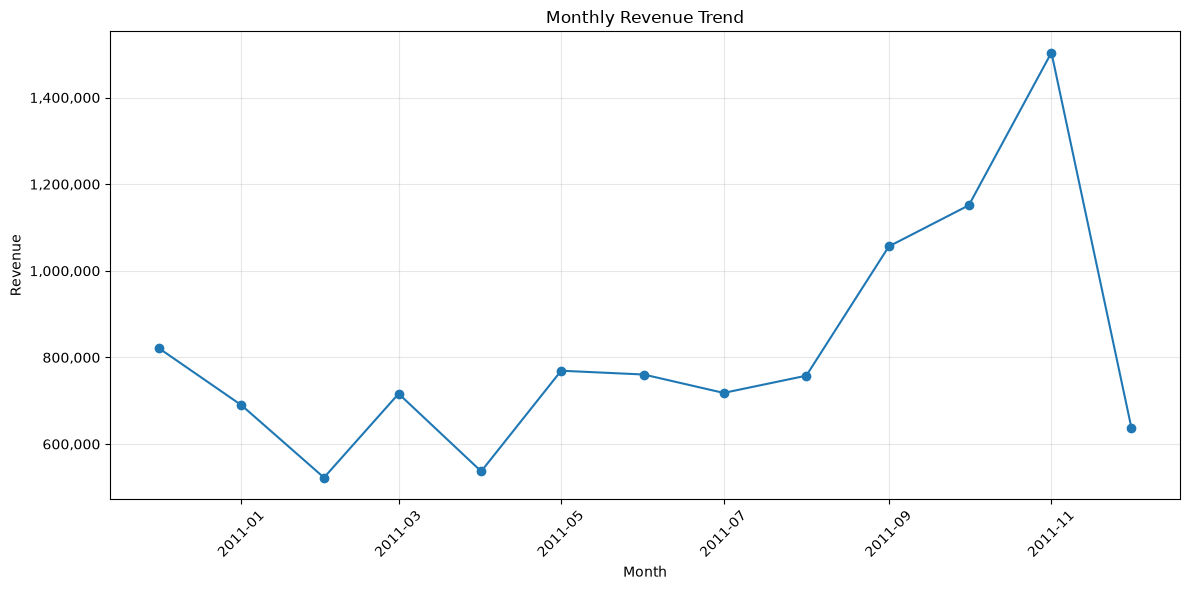

In [178]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue['InvoiceDate'],
    monthly_revenue['total_revenue'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.5 Order Trend Visualization

In [179]:
monthly_orders = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))
      .agg(
          total_orders=('invoice_no_normalized', 'nunique')
      )
      .reset_index()
)

monthly_orders['InvoiceDate'] = monthly_orders['InvoiceDate'].dt.to_timestamp()

monthly_orders

,InvoiceDate,total_orders
0,2010-12-01,1559
1,2011-01-01,1086
2,2011-02-01,1100
3,2011-03-01,1454
4,2011-04-01,1246
5,2011-05-01,1681
6,2011-06-01,1533
7,2011-07-01,1475
8,2011-08-01,1361
9,2011-09-01,1837


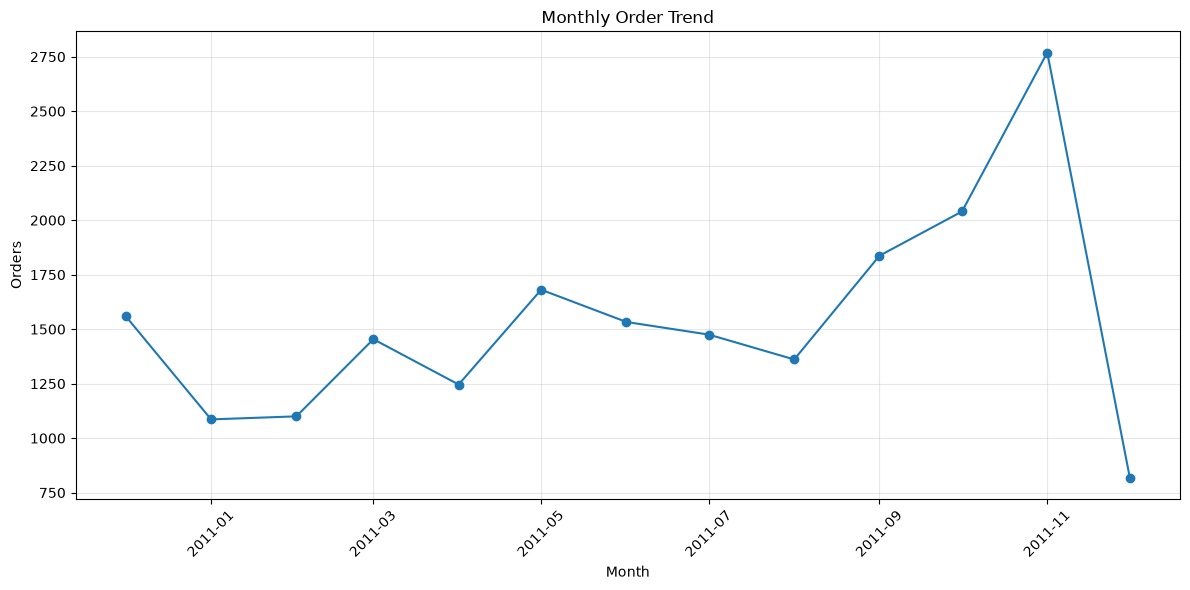

In [180]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders['InvoiceDate'],
    monthly_orders['total_orders'],
    marker='o'
)

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Orders')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.6 Quantity Trend Visualization

In [181]:
monthly_quantity = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))
      .agg(
          total_quantity=('Quantity', 'sum')
      )
      .reset_index()
)

monthly_quantity['InvoiceDate'] = monthly_quantity['InvoiceDate'].dt.to_timestamp()

monthly_quantity

,InvoiceDate,total_quantity
0,2010-12-01,358019
1,2011-01-01,387099
2,2011-02-01,282934
3,2011-03-01,376599
4,2011-04-01,307953
5,2011-05-01,395001
6,2011-06-01,388511
7,2011-07-01,399693
8,2011-08-01,421020
9,2011-09-01,569573


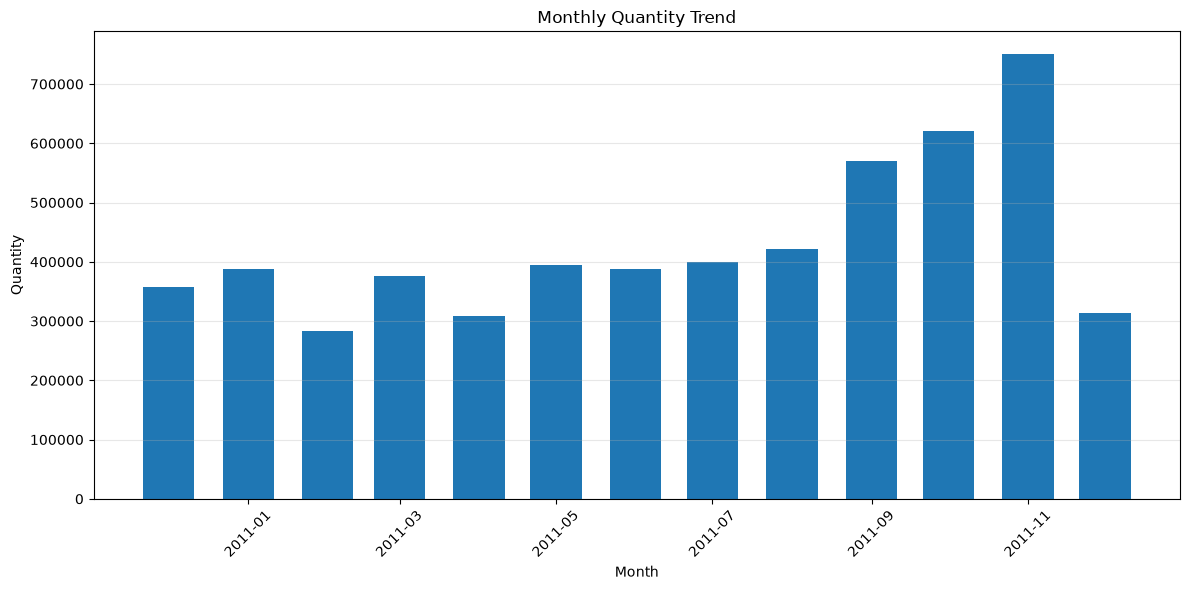

In [182]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_quantity['InvoiceDate'],
    monthly_quantity['total_quantity'],
    width=20
)

plt.title('Monthly Quantity Trend')
plt.xlabel('Month')
plt.ylabel('Quantity')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 2.7 Monthly / Weekly / Daily Sales Pattern

### 2.7.1 Monthly Sales Pattern

In [183]:
monthly_pattern = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))
      .agg(
          total_orders=('invoice_no_normalized', 'nunique'),
          total_quantity=('Quantity', 'sum'),
          total_revenue=('Revenue', 'sum'),
          active_days=('InvoiceDate', lambda x: x.dt.date.nunique())
      )
      .reset_index()
)

monthly_pattern['InvoiceDate'] = monthly_pattern['InvoiceDate'].dt.to_timestamp()

monthly_pattern['average_daily_revenue'] = (
    monthly_pattern['total_revenue']
    / monthly_pattern['active_days']
)

monthly_pattern

,InvoiceDate,total_orders,total_quantity,total_revenue,active_days,average_daily_revenue
0,2010-12-01,1559,358019,"821,452.73",20,"41,072.64"
1,2011-01-01,1086,387099,"689,811.61",24,"28,742.15"
2,2011-02-01,1100,282934,"522,545.56",24,"21,772.73"
3,2011-03-01,1454,376599,"716,215.26",27,"26,526.49"
4,2011-04-01,1246,307953,"536,968.49",21,"25,569.93"
5,2011-05-01,1681,395001,"769,296.61",25,"30,771.86"
6,2011-06-01,1533,388511,"760,547.01",26,"29,251.81"
7,2011-07-01,1475,399693,"718,076.12",26,"27,618.31"
8,2011-08-01,1361,421020,"757,841.38",26,"29,147.75"
9,2011-09-01,1837,569573,"1,056,435.19",26,"40,632.12"


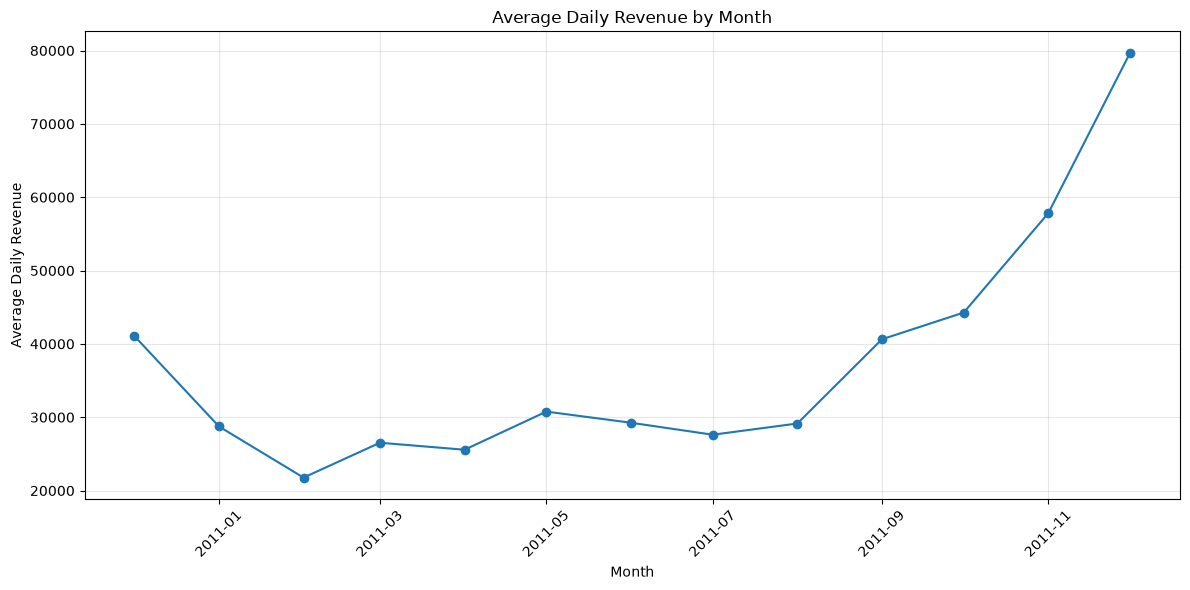

In [184]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_pattern['InvoiceDate'],
    monthly_pattern['average_daily_revenue'],
    marker='o'
)

plt.title('Average Daily Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Revenue')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.7.2 Weekly Sales Pattern

In [185]:
df['weekday'] = df['InvoiceDate'].dt.day_name()

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

In [186]:
weekly_pattern = (
    df.groupby('weekday')
      .agg(
          total_orders=('invoice_no_normalized', 'nunique'),
          total_quantity=('Quantity', 'sum'),
          total_revenue=('Revenue', 'sum')
      )
      .reindex(weekday_order)
      .reset_index()
)

weekly_pattern

,weekday,total_orders,total_quantity,total_revenue
0,Monday,"3,126.00","871,148.00","1,775,782.07"
1,Tuesday,"3,554.00","1,113,087.00","2,175,700.51"
2,Wednesday,"3,690.00","1,025,093.00","1,847,074.38"
3,Thursday,"4,246.00","1,207,384.00","2,199,292.57"
4,Friday,"3,140.00","890,199.00","1,837,470.49"
5,Saturday,NaN,NaN,NaN
6,Sunday,"2,204.00","465,509.00","806,790.78"


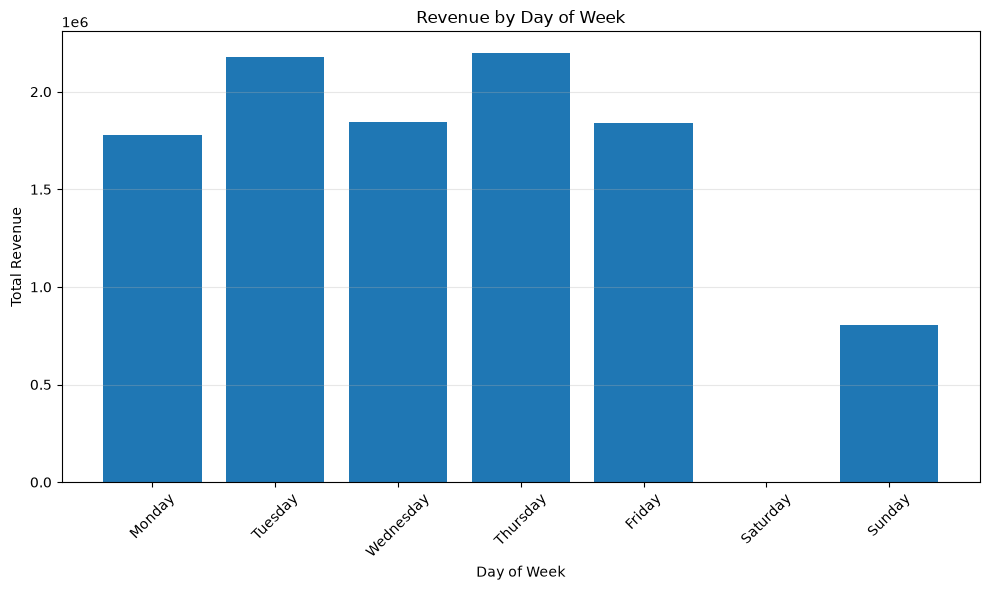

In [187]:
plt.figure(figsize=(10, 6))

plt.bar(
    weekly_pattern['weekday'],
    weekly_pattern['total_revenue']
)

plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

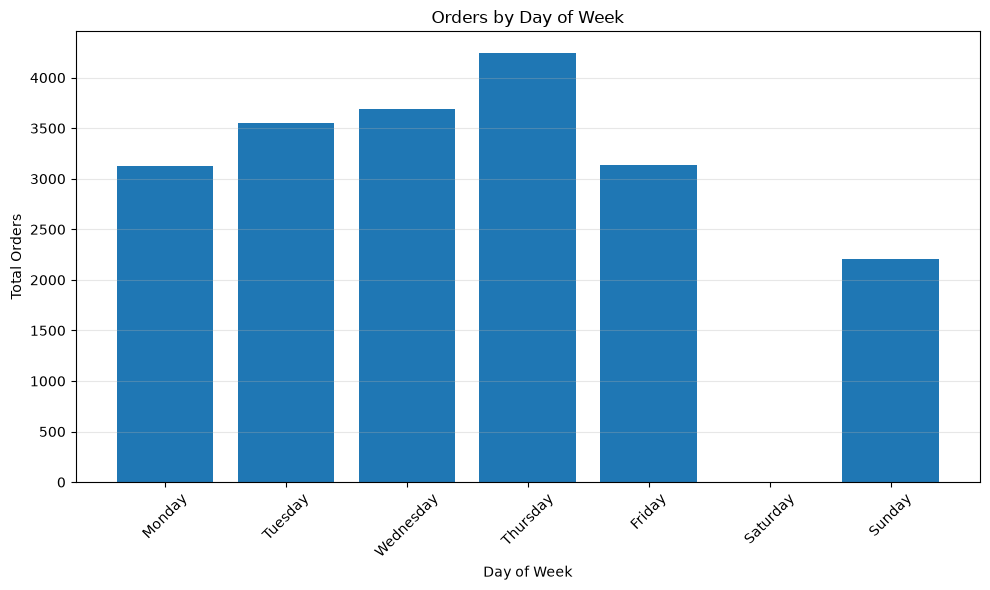

In [188]:
plt.figure(figsize=(10, 6))

plt.bar(
    weekly_pattern['weekday'],
    weekly_pattern['total_orders']
)

plt.title('Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Orders')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.7.3 Daily Sales Pattern

In [189]:
daily_pattern = (
    df.groupby(df['InvoiceDate'].dt.date)
      .agg(
          total_orders=('invoice_no_normalized', 'nunique'),
          total_quantity=('Quantity', 'sum'),
          total_revenue=('Revenue', 'sum')
      )
      .reset_index()
)

daily_pattern.rename(
    columns={'InvoiceDate': 'sales_date'},
    inplace=True
)

daily_pattern.head()

,sales_date,total_orders,total_quantity,total_revenue
0,2010-12-01,127,26818,"58,776.79"
1,2010-12-02,142,31264,"47,629.42"
2,2010-12-03,68,16158,"46,898.63"
3,2010-12-05,88,16242,"31,364.63"
4,2010-12-06,102,21619,"54,624.15"


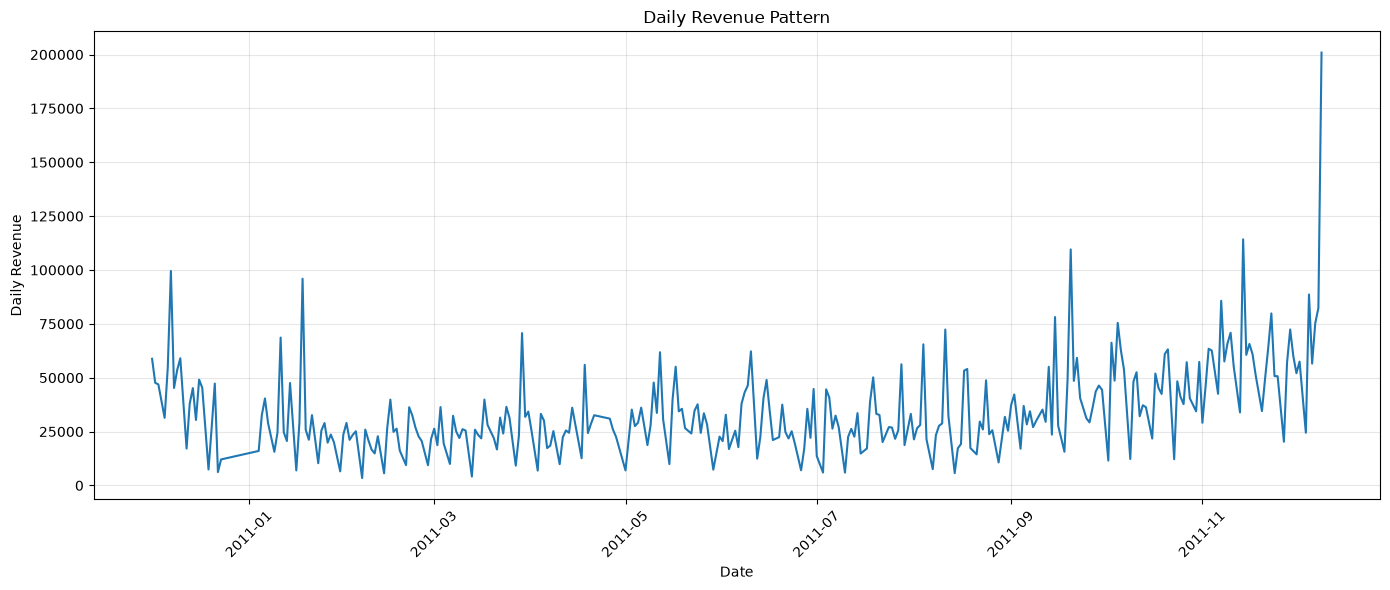

In [190]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_pattern['sales_date'],
    daily_pattern['total_revenue']
)

plt.title('Daily Revenue Pattern')
plt.xlabel('Date')
plt.ylabel('Daily Revenue')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.7.4 Daily Revenue Distribution

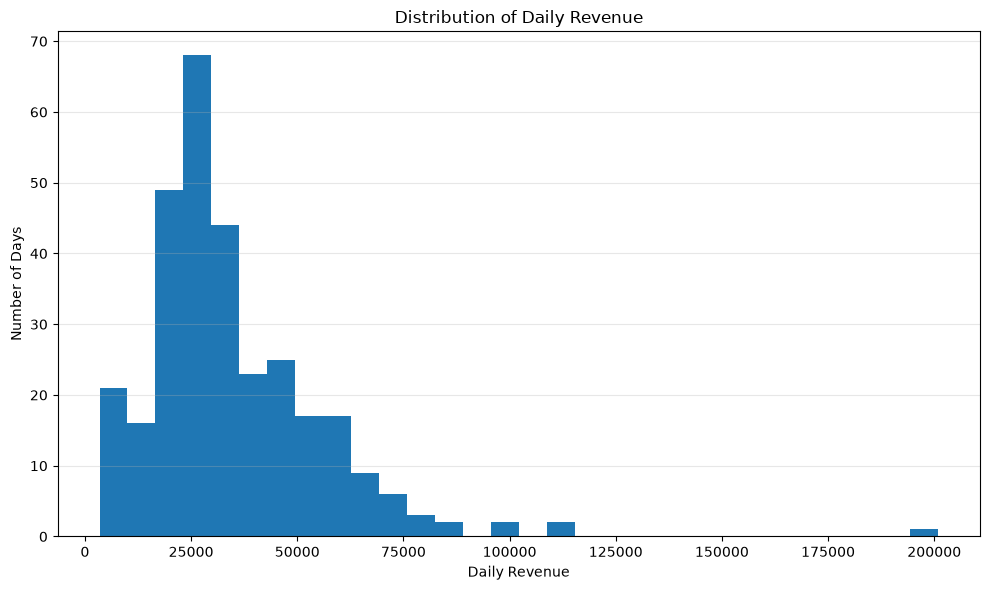

In [191]:
plt.figure(figsize=(10, 6))

plt.hist(
    daily_pattern['total_revenue'],
    bins=30
)

plt.title('Distribution of Daily Revenue')
plt.xlabel('Daily Revenue')
plt.ylabel('Number of Days')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [192]:
daily_revenue = daily_pattern['total_revenue']

print(f"Number of active days : {daily_revenue.count():,}")
print(f"Minimum daily revenue : {daily_revenue.min():,.2f}")
print(f"Maximum daily revenue : {daily_revenue.max():,.2f}")
print(f"Mean daily revenue    : {daily_revenue.mean():,.2f}")
print(f"Median daily revenue  : {daily_revenue.median():,.2f}")

Number of active days : 305
Minimum daily revenue : 3,439.67
Maximum daily revenue : 200,900.98
Mean daily revenue    : 34,892.17
Median daily revenue  : 29,526.29


## 2.8 Transaction / Order Value Distribution

### 2.8.1 Calculate Order Value

In [193]:
order_value = (
    df.groupby('invoice_no_normalized', as_index=False)
      .agg(
          order_value=('Revenue', 'sum')
      )
)

order_value.head()

,invoice_no_normalized,order_value
0,536365,139.12
1,536366,22.20
2,536367,278.73
3,536368,70.05
4,536369,17.85


In [194]:
order_value['order_value'].describe()

count    19,960.00
mean        533.17
std       1,780.41
min           0.38
25%         151.70
50%         303.30
75%         493.46
max     168,469.60
Name: order_value, dtype: float64

### 2.8.2 Histogram Order Value Distribution

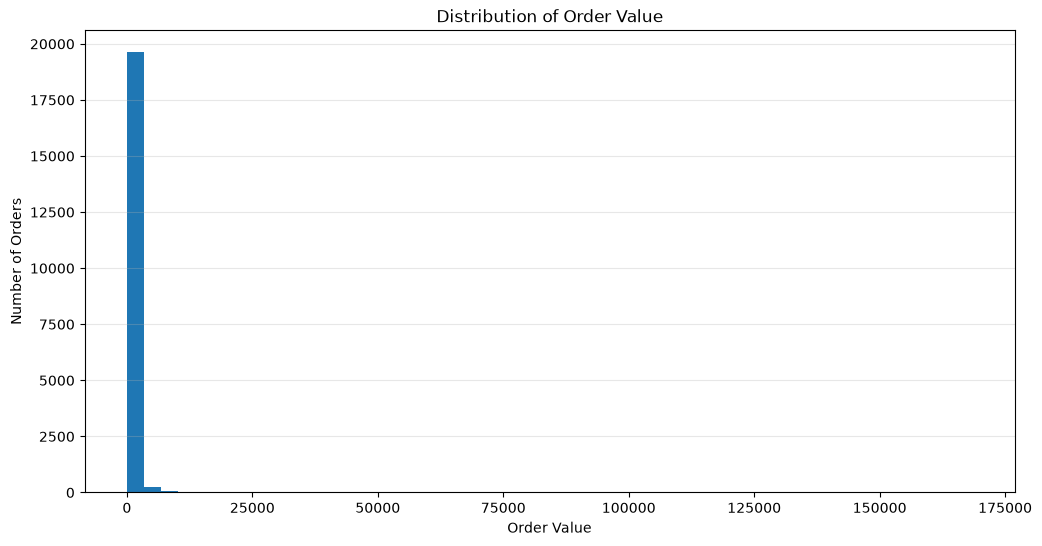

In [195]:
plt.figure(figsize=(12, 6))

plt.hist(
    order_value['order_value'],
    bins=50
)

plt.title('Distribution of Order Value')
plt.xlabel('Order Value')
plt.ylabel('Number of Orders')

plt.grid(axis='y', alpha=0.3)
plt.show()

### 2.8.3 Boxplot & Outlier Analysis

#### 2.8.3.1 Boxplot Order Value

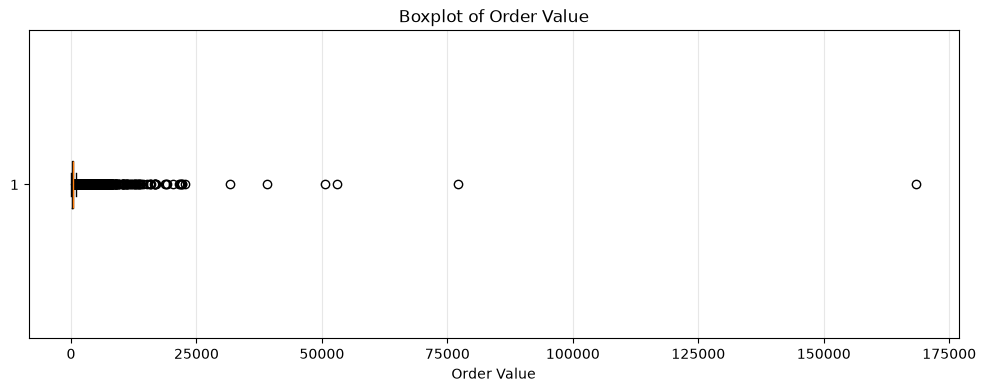

In [196]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    order_value['order_value'],
    orientation='horizontal'
)

plt.title('Boxplot of Order Value')
plt.xlabel('Order Value')

plt.grid(axis='x', alpha=0.3)
plt.show()

#### 2.8.3.2 Calculate IQR & Outlier Boundaries

In [197]:
Q1 = order_value['order_value'].quantile(0.25)
Q3 = order_value['order_value'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1           : {Q1:,.2f}")
print(f"Q3           : {Q3:,.2f}")
print(f"IQR          : {IQR:,.2f}")
print(f"Lower bound  : {lower_bound:,.2f}")
print(f"Upper bound  : {upper_bound:,.2f}")

Q1           : 151.70
Q3           : 493.46
IQR          : 341.77
Lower bound  : -360.96
Upper bound  : 1,006.11


#### 2.8.3.3 Identify Outliers

In [198]:
outliers = order_value[
    (order_value['order_value'] < lower_bound) |
    (order_value['order_value'] > upper_bound)
].copy()

print(f"Outlier orders : {len(outliers):,}")
print(
    f"Outlier rate   : "
    f"{len(outliers) / len(order_value) * 100:.2f}%"
)

Outlier orders : 1,811
Outlier rate   : 9.07%


In [199]:
outliers.sort_values(
    'order_value',
    ascending=False
).head(10)

,invoice_no_normalized,order_value
19923,581483,"168,469.60"
2116,541431,"77,183.60"
16923,574941,"52,940.94"
17579,576365,"50,653.91"
8693,556444,"38,970.00"
13545,567423,"31,698.16"
8899,556917,"22,775.93"
15693,572209,"22,206.00"
13537,567381,"22,104.80"
11881,563614,"21,880.44"


# 3. Customer Behavior

## 3.1 Customer Overview

### 3.1.1 Total Identified Customers

In [200]:
identified_customers = df['CustomerID'].dropna().nunique()

print(f"Total identified customers : {identified_customers:,}")

Total identified customers : 4,338


In [201]:
customer_coverage = (
    df['CustomerID'].notna().mean() * 100
)

print(f"Customer ID coverage       : {customer_coverage:.2f}%")

Customer ID coverage       : 74.82%


In [202]:
identified_rows = df['CustomerID'].notna().sum()

print(f"Rows with identified customer : {identified_rows:,}")
print(f"Rows without customer ID      : {df['CustomerID'].isna().sum():,}")

Rows with identified customer : 392,692
Rows without customer ID      : 132,186


### 3.1.2 Customer-level Summary

In [203]:
customer_summary = (
    df[df['CustomerID'].notna()]
    .groupby('CustomerID')
    .agg(
        total_revenue=('Revenue', 'sum'),
        total_orders=('invoice_no_normalized', 'nunique'),
        total_quantity=('Quantity', 'sum')
    )
    .reset_index()
)

customer_summary.head()

,CustomerID,total_revenue,total_orders,total_quantity
0,"12,346.00","77,183.60",1,74215
1,"12,347.00","4,310.00",7,2458
2,"12,348.00","1,797.24",4,2341
3,"12,349.00","1,757.55",1,631
4,"12,350.00",334.40,1,197


In [204]:
print(f"Customer summary rows : {len(customer_summary):,}")
print(f"Identified customers  : {identified_customers:,}")

print(
    f"Match : {len(customer_summary) == identified_customers}"
)

Customer summary rows : 4,338
Identified customers  : 4,338
Match : True


## 3.2 Revenue per Customer

In [205]:
revenue_per_customer = customer_summary[
    ['CustomerID', 'total_revenue']
].sort_values(
    'total_revenue',
    ascending=False
)

revenue_per_customer.head(10)

,CustomerID,total_revenue
1689,"14,646.00","280,206.02"
4201,"18,102.00","259,657.30"
3728,"17,450.00","194,390.79"
3008,"16,446.00","168,472.50"
1879,"14,911.00","143,711.17"
55,"12,415.00","124,914.53"
1333,"14,156.00","117,210.08"
3771,"17,511.00","91,062.38"
2702,"16,029.00","80,850.84"
0,"12,346.00","77,183.60"


In [206]:
revenue_per_customer['total_revenue'].describe()

count     4,338.00
mean      2,048.69
std       8,985.23
min           3.75
25%         306.48
50%         668.57
75%       1,660.60
max     280,206.02
Name: total_revenue, dtype: float64

## 3.3 Orders per Customer

In [207]:
orders_per_customer = customer_summary[
    ['CustomerID', 'total_orders']
].sort_values(
    'total_orders',
    ascending=False
)

orders_per_customer.head(10)

,CustomerID,total_orders
326,"12,748.00",209
1879,"14,911.00",201
4010,"17,841.00",124
562,"13,089.00",97
1661,"14,606.00",93
2176,"15,311.00",91
481,"12,971.00",86
1689,"14,646.00",73
2702,"16,029.00",63
795,"13,408.00",62


In [208]:
orders_per_customer['total_orders'].describe()

count   4,338.00
mean        4.27
std         7.70
min         1.00
25%         1.00
50%         2.00
75%         5.00
max       209.00
Name: total_orders, dtype: float64

## 3.4 Quantity per Customer

In [209]:
quantity_per_customer = customer_summary[
    ['CustomerID', 'total_quantity']
].sort_values(
    'total_quantity',
    ascending=False
)

quantity_per_customer.head(10)

,CustomerID,total_quantity
1689,"14,646.00",196915
3008,"16,446.00",80997
1879,"14,911.00",80240
55,"12,415.00",77374
0,"12,346.00",74215
3728,"17,450.00",69973
3771,"17,511.00",64549
4201,"18,102.00",64124
996,"13,694.00",63312
1434,"14,298.00",58343


In [210]:
quantity_per_customer['total_quantity'].describe()

count     4,338.00
mean      1,187.64
std       5,043.62
min           1.00
25%         159.00
50%         378.00
75%         989.75
max     196,915.00
Name: total_quantity, dtype: float64

## 3.5 Customer Purchase Frequency

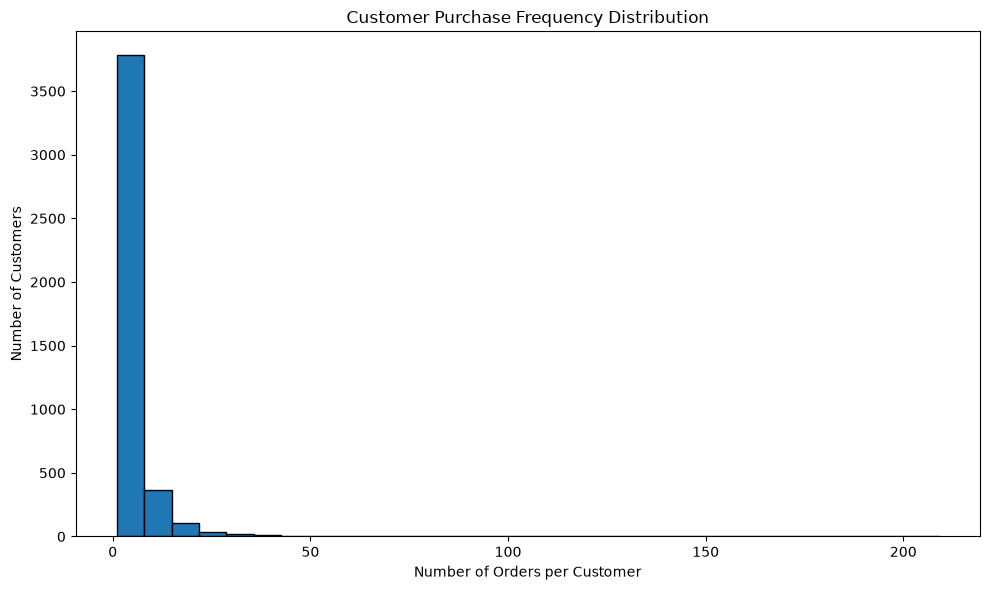

In [211]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_summary['total_orders'],
    bins=30,
    edgecolor='black'
)

plt.title('Customer Purchase Frequency Distribution')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

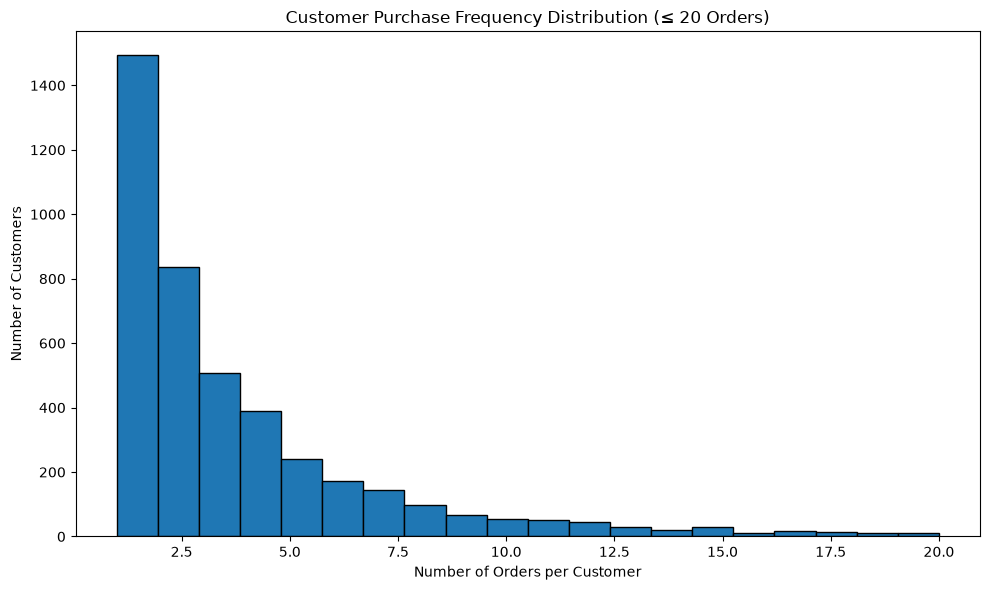

In [212]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_summary.loc[
        customer_summary['total_orders'] <= 20,
        'total_orders'
    ],
    bins=20,
    edgecolor='black'
)

plt.title('Customer Purchase Frequency Distribution (≤ 20 Orders)')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

## 3.6 Customer Revenue Distribution

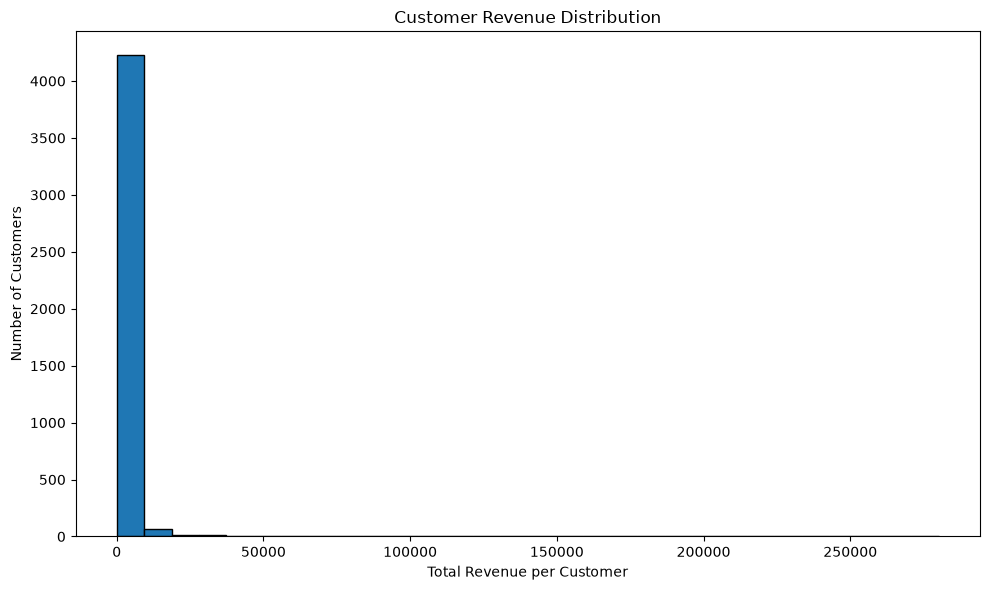

In [213]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_summary['total_revenue'],
    bins=30,
    edgecolor='black'
)

plt.title('Customer Revenue Distribution')
plt.xlabel('Total Revenue per Customer')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

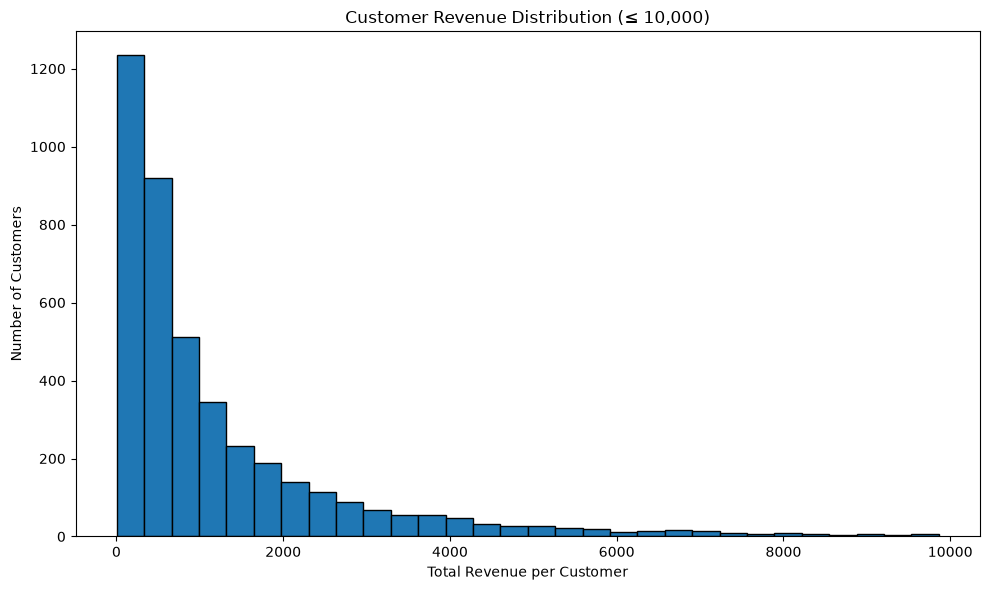

In [214]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_summary.loc[
        customer_summary['total_revenue'] <= 10000,
        'total_revenue'
    ],
    bins=30,
    edgecolor='black'
)

plt.title('Customer Revenue Distribution (≤ 10,000)')
plt.xlabel('Total Revenue per Customer')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

## 3.7 Customer Revenue — Boxplot & Outlier Analysis

### 3.7.1 Boxplot

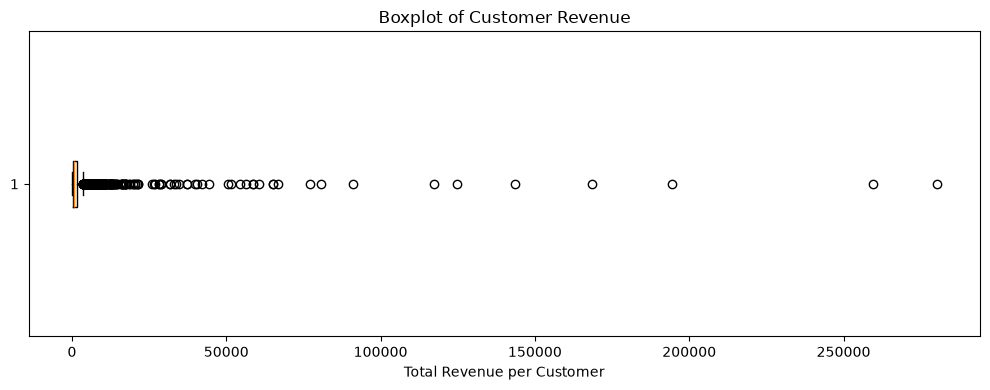

In [215]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    customer_summary['total_revenue'],
    orientation='horizontal'
)

plt.title('Boxplot of Customer Revenue')
plt.xlabel('Total Revenue per Customer')

plt.tight_layout()
plt.show()

### 3.7.2 Calculate IQR & Outlier Bounds

In [216]:
Q1 = customer_summary['total_revenue'].quantile(0.25)
Q3 = customer_summary['total_revenue'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1           : {Q1:,.2f}")
print(f"Q3           : {Q3:,.2f}")
print(f"IQR          : {IQR:,.2f}")
print(f"Lower bound  : {lower_bound:,.2f}")
print(f"Upper bound  : {upper_bound:,.2f}")

Q1           : 306.48
Q3           : 1,660.60
IQR          : 1,354.11
Lower bound  : -1,724.69
Upper bound  : 3,691.77


### 3.7.3 Outlier Analysis

In [217]:
outlier_mask = (
    (customer_summary['total_revenue'] < lower_bound) |
    (customer_summary['total_revenue'] > upper_bound)
)

total_customers = len(customer_summary)
outlier_customers = outlier_mask.sum()

outlier_rate = (
    outlier_customers / total_customers * 100
)

print(f"Total customers : {total_customers:,}")
print(f"Outlier customers : {outlier_customers:,}")
print(f"Outlier rate : {outlier_rate:.2f}%")

Total customers : 4,338
Outlier customers : 425
Outlier rate : 9.80%


In [218]:
customer_summary.loc[
    outlier_mask,
    ['CustomerID', 'total_revenue']
].sort_values(
    'total_revenue',
    ascending=False
).head(10)

,CustomerID,total_revenue
1689,"14,646.00","280,206.02"
4201,"18,102.00","259,657.30"
3728,"17,450.00","194,390.79"
3008,"16,446.00","168,472.50"
1879,"14,911.00","143,711.17"
55,"12,415.00","124,914.53"
1333,"14,156.00","117,210.08"
3771,"17,511.00","91,062.38"
2702,"16,029.00","80,850.84"
0,"12,346.00","77,183.60"


## 3.8 Top 10 Customers

### 3.8.1 Top 10 Customers by Revenue

In [219]:
top_10_customers = (
    customer_summary[
        ['CustomerID', 'total_revenue']
    ]
    .sort_values(
        'total_revenue',
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top_10_customers

,CustomerID,total_revenue
0,"14,646.00","280,206.02"
1,"18,102.00","259,657.30"
2,"17,450.00","194,390.79"
3,"16,446.00","168,472.50"
4,"14,911.00","143,711.17"
5,"12,415.00","124,914.53"
6,"14,156.00","117,210.08"
7,"17,511.00","91,062.38"
8,"16,029.00","80,850.84"
9,"12,346.00","77,183.60"


In [220]:
top_10_customers.insert(
    0,
    'rank',
    range(1, len(top_10_customers) + 1)
)

top_10_customers

,rank,CustomerID,total_revenue
0,1,"14,646.00","280,206.02"
1,2,"18,102.00","259,657.30"
2,3,"17,450.00","194,390.79"
3,4,"16,446.00","168,472.50"
4,5,"14,911.00","143,711.17"
5,6,"12,415.00","124,914.53"
6,7,"14,156.00","117,210.08"
7,8,"17,511.00","91,062.38"
8,9,"16,029.00","80,850.84"
9,10,"12,346.00","77,183.60"


### 3.8.2 Top 10 Customers Bar Chart

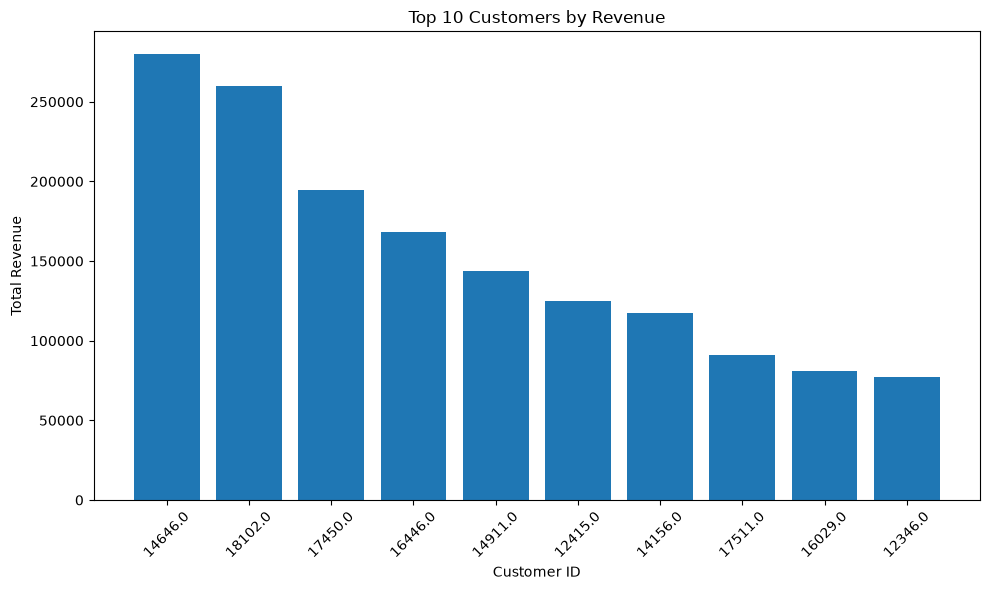

In [221]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_10_customers['CustomerID'].astype(str),
    top_10_customers['total_revenue']
)

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3.8.3 Top 10 Revenue Contribution

In [222]:
top_10_revenue = top_10_customers['total_revenue'].sum()

identified_customer_revenue = customer_summary['total_revenue'].sum()

top_10_contribution = (
    top_10_revenue /
    identified_customer_revenue
    * 100
)

print(f"Top 10 revenue           : {top_10_revenue:,.2f}")
print(f"Identified customer revenue : {identified_customer_revenue:,.2f}")
print(f"Top 10 contribution      : {top_10_contribution:.2f}%")

Top 10 revenue           : 1,537,659.21
Identified customer revenue : 8,887,208.89
Top 10 contribution      : 17.30%


## 3.9 Customer Concentration / Pareto Analysis

### 3.9.1 Customer Revenue Ranking

In [223]:
customer_pareto = (
    customer_summary[
        ['CustomerID', 'total_revenue']
    ]
    .sort_values(
        'total_revenue',
        ascending=False
    )
    .reset_index(drop=True)
)

customer_pareto['customer_rank'] = (
    customer_pareto.index + 1
)

customer_pareto.head(10)

,CustomerID,total_revenue,customer_rank
0,"14,646.00","280,206.02",1
1,"18,102.00","259,657.30",2
2,"17,450.00","194,390.79",3
3,"16,446.00","168,472.50",4
4,"14,911.00","143,711.17",5
5,"12,415.00","124,914.53",6
6,"14,156.00","117,210.08",7
7,"17,511.00","91,062.38",8
8,"16,029.00","80,850.84",9
9,"12,346.00","77,183.60",10


### 3.9.2 Cumulative Revenue

In [224]:
customer_pareto['cumulative_revenue'] = (
    customer_pareto['total_revenue']
    .cumsum()
)

total_customer_revenue = (
    customer_pareto['total_revenue'].sum()
)

customer_pareto['cumulative_revenue_pct'] = (
    customer_pareto['cumulative_revenue']
    / total_customer_revenue
    * 100
)

customer_pareto.head(10)

,CustomerID,total_revenue,customer_rank,cumulative_revenue,cumulative_revenue_pct
0,"14,646.00","280,206.02",1,"280,206.02",3.15
1,"18,102.00","259,657.30",2,"539,863.32",6.07
2,"17,450.00","194,390.79",3,"734,254.11",8.26
3,"16,446.00","168,472.50",4,"902,726.61",10.16
4,"14,911.00","143,711.17",5,"1,046,437.78",11.77
5,"12,415.00","124,914.53",6,"1,171,352.31",13.18
6,"14,156.00","117,210.08",7,"1,288,562.39",14.50
7,"17,511.00","91,062.38",8,"1,379,624.77",15.52
8,"16,029.00","80,850.84",9,"1,460,475.61",16.43
9,"12,346.00","77,183.60",10,"1,537,659.21",17.30


### 3.9.3 Revenue Contribution per Customer

In [225]:
customer_pareto['revenue_contribution_pct'] = (
    customer_pareto['total_revenue']
    / total_customer_revenue
    * 100
)

customer_pareto.head(10)

,CustomerID,total_revenue,customer_rank,cumulative_revenue,cumulative_revenue_pct,revenue_contribution_pct
0,"14,646.00","280,206.02",1,"280,206.02",3.15,3.15
1,"18,102.00","259,657.30",2,"539,863.32",6.07,2.92
2,"17,450.00","194,390.79",3,"734,254.11",8.26,2.19
3,"16,446.00","168,472.50",4,"902,726.61",10.16,1.90
4,"14,911.00","143,711.17",5,"1,046,437.78",11.77,1.62
5,"12,415.00","124,914.53",6,"1,171,352.31",13.18,1.41
6,"14,156.00","117,210.08",7,"1,288,562.39",14.50,1.32
7,"17,511.00","91,062.38",8,"1,379,624.77",15.52,1.02
8,"16,029.00","80,850.84",9,"1,460,475.61",16.43,0.91
9,"12,346.00","77,183.60",10,"1,537,659.21",17.30,0.87


### 3.9.4 Pareto-Style Visualization

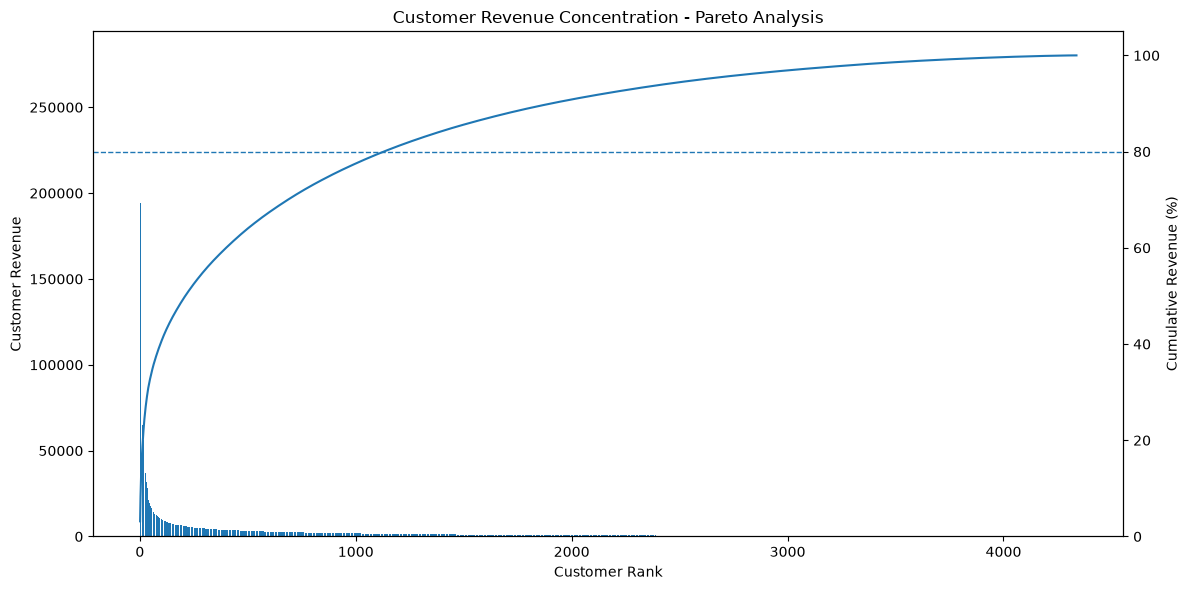

In [226]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Revenue bars
ax1.bar(
    customer_pareto['customer_rank'],
    customer_pareto['total_revenue']
)

ax1.set_xlabel('Customer Rank')
ax1.set_ylabel('Customer Revenue')

# Cumulative Percentage
ax2 = ax1.twinx()

ax2.plot(
    customer_pareto['customer_rank'],
    customer_pareto['cumulative_revenue_pct']
)

ax2.axhline(
    80,
    linestyle='--',
    linewidth=1
)

ax2.set_ylabel('Cumulative Revenue (%)')
ax2.set_ylim(0, 105)

plt.title('Customer Revenue Concentration - Pareto Analysis')

plt.tight_layout()
plt.show()

### 3.9.5 Key Concentration Metrics

In [227]:
checkpoints = [10, 20, 50, 100, 500, 1000]

for n in checkpoints:
    revenue = customer_pareto.loc[
        :n-1,
        'total_revenue'
    ].sum()

    contribution = (
        revenue /
        total_customer_revenue
        * 100
    )

    print(
        f"Top {n:>4} customers : "
        f"{revenue:,.2f}"
        f"({contribution:.2f}%)"
    )

Top   10 customers : 1,537,659.21(17.30%)
Top   20 customers : 2,125,228.46(23.91%)
Top   50 customers : 2,959,341.54(33.30%)
Top  100 customers : 3,608,854.55(40.61%)
Top  500 customers : 5,690,393.36(64.03%)
Top 1000 customers : 6,890,548.48(77.53%)


In [228]:
customer_for_80 = (
    customer_pareto[
        customer_pareto['cumulative_revenue_pct'] >= 80
    ]
    .iloc[0]
)

print(
    "Customers required to reach 80% revenue :",
    int(customer_for_80['customer_rank'])
)

print(
    "Customer percentage :",
    f"{customer_for_80['customer_rank'] / len(customer_pareto) * 100:.2f}%"
)

print(
    "Cumulative revenue :",
    f"{customer_for_80['cumulative_revenue_pct']:.2f}%"
)

Customers required to reach 80% revenue : 1130
Customer percentage : 26.05%
Cumulative revenue : 80.01%


# 4. Country Analysis

## 4.1 Revenue by Country

In [229]:
country_revenue = (
    df.groupby('Country', as_index=False)
      .agg(total_revenue=('Revenue', 'sum'))
      .sort_values('total_revenue', ascending=False)
      .reset_index(drop=True)
)

country_revenue

,Country,total_revenue
0,United Kingdom,"9,001,744.09"
1,Netherlands,"285,446.34"
2,EIRE,"283,140.52"
3,Germany,"228,678.40"
4,France,"209,625.37"
5,Australia,"138,453.81"
6,Spain,"61,558.56"
7,Switzerland,"57,067.60"
8,Belgium,"41,196.34"
9,Sweden,"38,367.83"


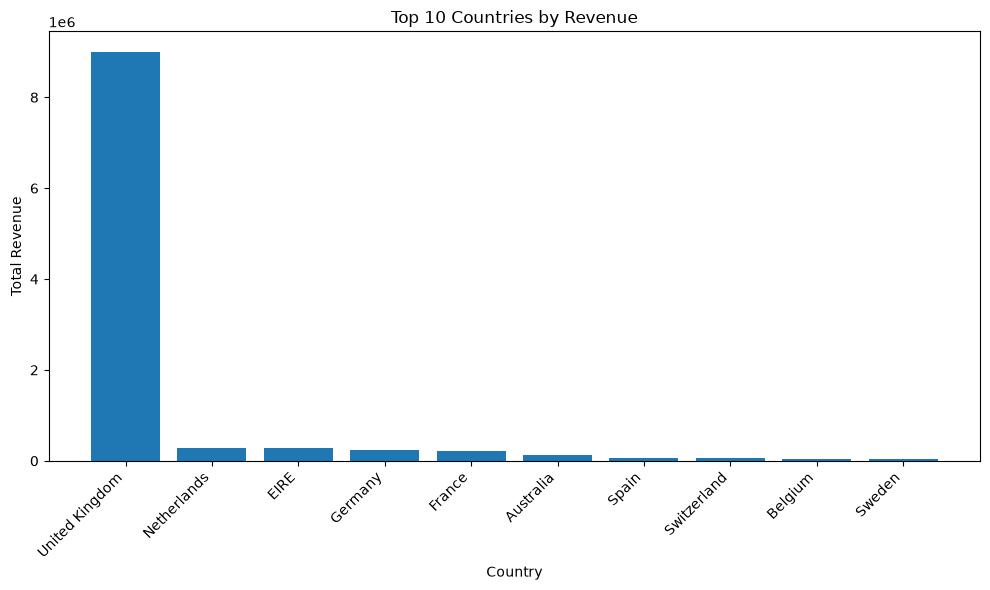

In [230]:
top_10_country_revenue = country_revenue.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_country_revenue['Country'],
    top_10_country_revenue['total_revenue']
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4.2 Orders by Country

In [231]:
orders_by_country = (
    df.groupby('Country')
      .agg(
          total_orders=('invoice_no_normalized', 'nunique')
      )
      .sort_values('total_orders', ascending=False)
      .reset_index()
)

orders_by_country

,Country,total_orders
0,United Kingdom,18019
1,Germany,457
2,France,392
3,EIRE,288
4,Belgium,98
5,Netherlands,94
6,Spain,90
7,Portugal,58
8,Australia,57
9,Switzerland,54


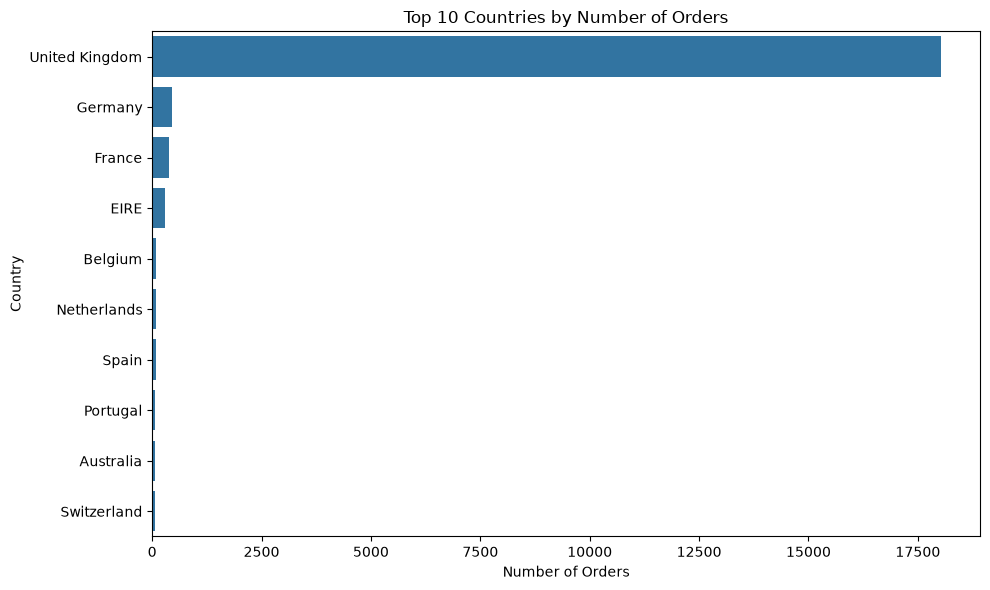

In [232]:
top_10_orders = orders_by_country.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10_orders,
    x='total_orders',
    y='Country'
)

plt.title('Top 10 Countries by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

## 4.3 Customers by Country

### 4.3.1 Customers Summary by Country

In [233]:
country_customers = (
    df[df['CustomerID'].notna()]
    .groupby('Country')
    .agg(
        total_customers=('CustomerID', 'nunique')
    )
    .sort_values('total_customers', ascending=False)
    .reset_index()
)

country_customers

,Country,total_customers
0,United Kingdom,3920
1,Germany,94
2,France,87
3,Spain,30
4,Belgium,25
5,Switzerland,21
6,Portugal,19
7,Italy,14
8,Finland,12
9,Austria,11


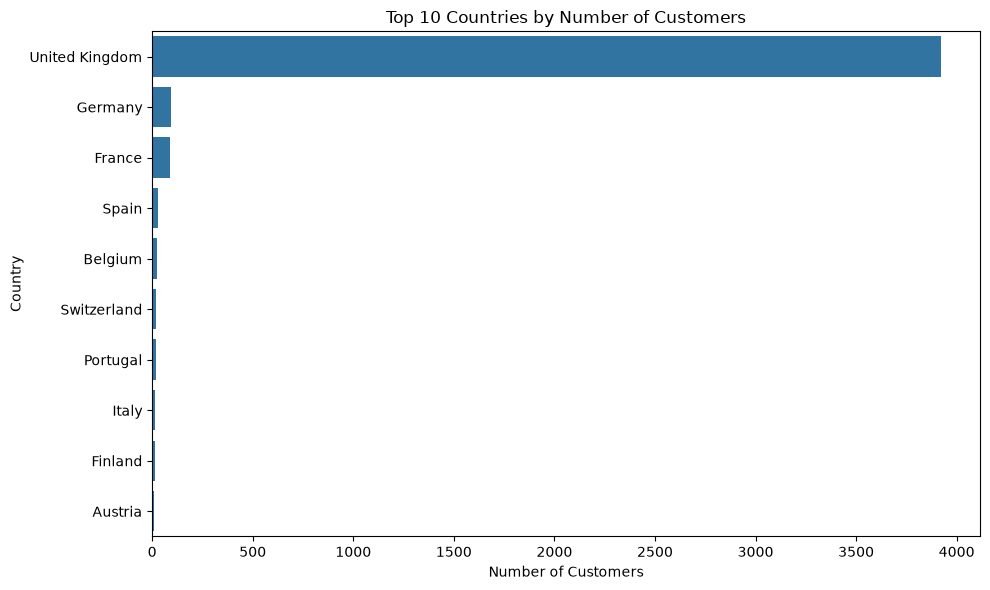

In [234]:
top_10_customers_country = country_customers.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10_customers_country,
    x='total_customers',
    y='Country'
)

plt.title('Top 10 Countries by Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [235]:
source_customers = (
    df[df['CustomerID'].notna()]
    ['CustomerID']
    .nunique()
)

country_customer_total = country_customers['total_customers'].sum()

print(f"Unique identified customers : {source_customers:,}")
print(f"Country aggregated customers: {country_customer_total:,}")
print(f"Difference                  : {country_customer_total - source_customers:,}")
print(
    f"Match                       : "
    f"{country_customer_total == source_customers}"
)

print()

print(
    f"Unique countries in source  : "
    f"{df['Country'].nunique():,}"
)

print(
    f"Countries in summary        : "
    f"{country_customers['Country'].nunique():,}"
)

print(
    f"Country count match         : "
    f"{df['Country'].nunique() == country_customers['Country'].nunique()}"
)

Unique identified customers : 4,338
Country aggregated customers: 4,346
Difference                  : 8
Match                       : False

Unique countries in source  : 38
Countries in summary        : 37
Country count match         : False


In [236]:
customer_country_check = (
    df[df['CustomerID'].notna()]
    .groupby('CustomerID')['Country']
    .nunique()
    .reset_index(name='country_count')
)

multi_country_customers = customer_country_check[
    customer_country_check['country_count'] > 1
]

print(
    "Customers associated with multiple countries :",
    len(multi_country_customers)
)

multi_country_customers

Customers associated with multiple countries : 8


,CustomerID,country_count
20,"12,370.00",2
38,"12,394.00",2
56,"12,417.00",2
60,"12,422.00",2
67,"12,429.00",2
69,"12,431.00",2
90,"12,455.00",2
92,"12,457.00",2


In [237]:
multi_country_details = (
    df[
        df['CustomerID'].isin(
            multi_country_customers['CustomerID']
        )
    ][['CustomerID', 'Country']]
    .drop_duplicates()
    .sort_values(['CustomerID', 'Country'])
)

multi_country_details

,CustomerID,Country
33051,"12,370.00",Austria
28641,"12,370.00",Cyprus
172016,"12,394.00",Belgium
371100,"12,394.00",Denmark
33219,"12,417.00",Belgium
165596,"12,417.00",Spain
61103,"12,422.00",Australia
231576,"12,422.00",Switzerland
162849,"12,429.00",Austria
19305,"12,429.00",Denmark


In [238]:
source_countries = set(df['Country'].dropna().unique())
summary_countries = set(country_customers['Country'])

missing_countries = source_countries - summary_countries

print("Countries missing from customer summary:")
print(missing_countries)

Countries missing from customer summary:
{'Hong Kong'}


In [239]:
for country in missing_countries:
    country_check = df[df['Country'] == country]

    print(f"\nCountry : {country}")
    print(
        "Rows :",
        len(country_check)
    )
    print(
        "Identified customers :",
        country_check['CustomerID'].notna().sum()
    )
    print(
        "Unique customers :",
        country_check['CustomerID'].nunique()
    )


Country : Hong Kong
Rows : 280
Identified customers : 0
Unique customers : 0


### 4.3.2 Customer Count Validation

In [240]:
unique_identified_customers = df.loc[
    df['CustomerID'].notna(),
    'CustomerID'
].nunique()

customer_country_associations = (
    df[df['CustomerID'].notna()]
    .groupby('Country')['CustomerID']
    .nunique()
    .sum()
)

multi_country_count = len(multi_country_customers)

print(
    f"Unique identified customers       : {unique_identified_customers:,}"
)

print(
    f"Customer-country associations     : {customer_country_associations:,}"
)

print(
    f"Customers in multiple countries   : {multi_country_count:,}"
)

print(
    f"Expected association count        : "
    f"{unique_identified_customers + multi_country_count:,}"
)

print(
    "Association validation            :",
    customer_country_associations ==
    unique_identified_customers + multi_country_count
)

Unique identified customers       : 4,338
Customer-country associations     : 4,346
Customers in multiple countries   : 8
Expected association count        : 4,346
Association validation            : True


### 4.3.3 Country Coverage Validation

In [241]:
source_countries = set(df['Country'].dropna().unique())

identified_customer_countries = set(
    df.loc[
        df['CustomerID'].notna(),
        'Country'
    ].unique()
)

countries_without_identified_customer = (
    source_countries - identified_customer_countries
)

print(
    f"Countries in source                 : "
    f"{len(source_countries)}"
)

print(
    f"Countries with identified customers : "
    f"{len(identified_customer_countries)}"
)

print(
    f"Countries without identified customer: "
    f"{len(countries_without_identified_customer)}"
)

print(
    "Countries without identified customer:",
    countries_without_identified_customer
)

Countries in source                 : 38
Countries with identified customers : 37
Countries without identified customer: 1
Countries without identified customer: {'Hong Kong'}


## 4.4 Average Revenue / Order by Country

In [242]:
country_aov = (
    df.groupby('Country')
    .agg(
        total_revenue=('Revenue', 'sum'),
        total_orders=('invoice_no_normalized', 'nunique')
    )
    .reset_index()
)

country_aov['average_revenue_per_order'] = (
    country_aov['total_revenue'] /
    country_aov['total_orders']
)

country_aov = country_aov.sort_values(
    'average_revenue_per_order',
    ascending=False
)

country_aov

,Country,total_revenue,total_orders,average_revenue_per_order
30,Singapore,"21,279.29",7,"3,039.90"
24,Netherlands,"285,446.34",94,"3,036.66"
0,Australia,"138,453.81",57,"2,429.01"
20,Japan,"37,416.37",19,"1,969.28"
21,Lebanon,"1,693.88",1,"1,693.88"
16,Hong Kong,"15,483.00",11,"1,407.55"
4,Brazil,"1,143.60",1,"1,143.60"
32,Sweden,"38,367.83",36,"1,065.77"
33,Switzerland,"57,067.60",54,"1,056.81"
9,Denmark,"18,955.34",18,"1,053.07"


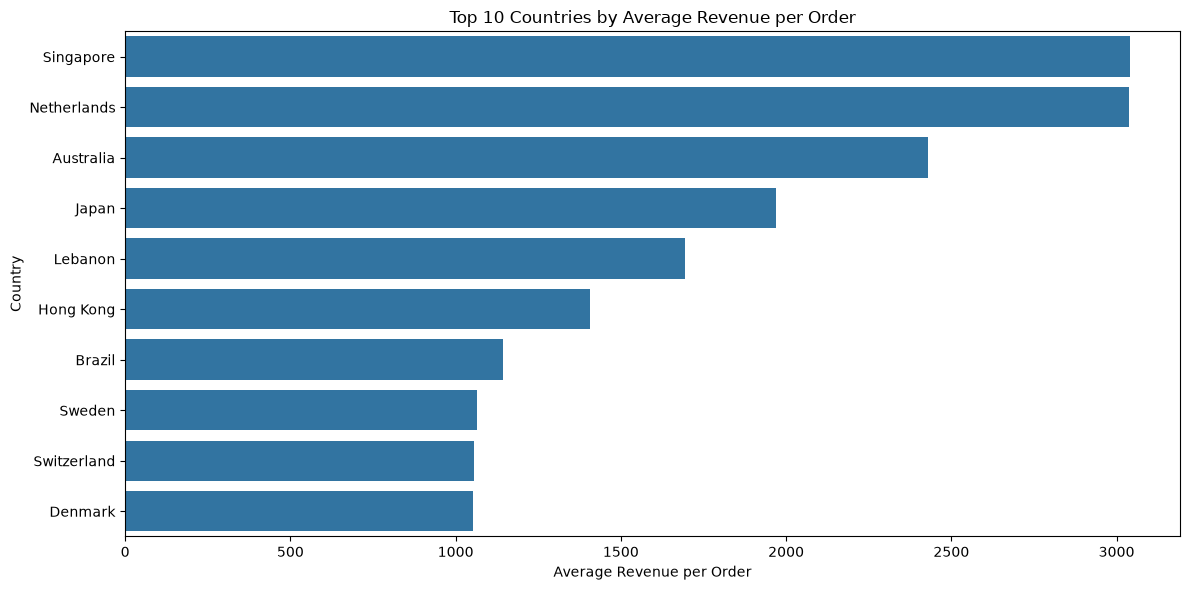

In [243]:
top_10_country_aov = country_aov.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_country_aov,
    x='average_revenue_per_order',
    y='Country'
)

plt.title('Top 10 Countries by Average Revenue per Order')
plt.xlabel('Average Revenue per Order')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

## 4.5 Country Contribution

In [244]:
country_contribution = country_aov[
    ['Country', 'total_revenue']
].copy()

overall_revenue = df['Revenue'].sum()

country_contribution['revenue_contribution_pct'] = (
    country_contribution['total_revenue']
    / overall_revenue
    * 100
)

country_contribution = country_contribution.sort_values(
    'total_revenue',
    ascending=False
).reset_index(drop=True)

country_contribution

,Country,total_revenue,revenue_contribution_pct
0,United Kingdom,"9,001,744.09",84.59
1,Netherlands,"285,446.34",2.68
2,EIRE,"283,140.52",2.66
3,Germany,"228,678.40",2.15
4,France,"209,625.37",1.97
5,Australia,"138,453.81",1.30
6,Spain,"61,558.56",0.58
7,Switzerland,"57,067.60",0.54
8,Belgium,"41,196.34",0.39
9,Sweden,"38,367.83",0.36


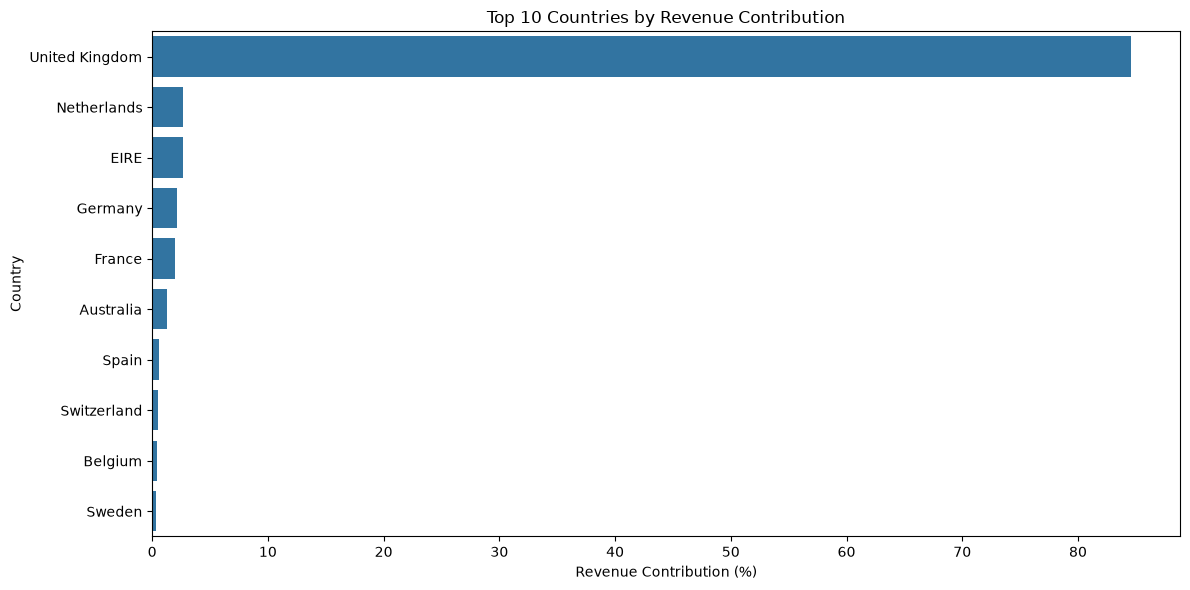

In [245]:
top_10_country_contribution = country_contribution.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_country_contribution,
    x='revenue_contribution_pct',
    y='Country'
)

plt.title('Top 10 Countries by Revenue Contribution')
plt.xlabel('Revenue Contribution (%)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [246]:
uk_revenue = df.loc[
    df['Country'] == 'United Kingdom',
    'Revenue'
].sum()

non_uk_revenue = df.loc[
    df['Country'] != 'United Kingdom',
    'Revenue'
].sum()

uk_contribution = uk_revenue / overall_revenue * 100
non_uk_contribution = non_uk_revenue / overall_revenue * 100

print(f"UK revenue      : {uk_revenue:,.2f}")
print(f"UK contribution : {uk_contribution:.2f}%")

print()

print(f"Non-UK revenue      : {non_uk_revenue:,.2f}")
print(f"Non-UK contribution : {non_uk_contribution:.2f}%")

UK revenue      : 9,001,744.09
UK contribution : 84.59%

Non-UK revenue      : 1,640,366.71
Non-UK contribution : 15.41%


## 4.6 UK vs Non-UK Performance

In [247]:
df['market_group'] = np.where(
    df['Country'] == 'United Kingdom',
    'UK',
    'Non-UK'
)

uk_non_uk_summary = (
    df.groupby('market_group')
      .agg(
          total_revenue=('Revenue', 'sum'),
          total_orders=('invoice_no_normalized', 'nunique'),
          total_quantity=('Quantity', 'sum'),
          total_customers=('CustomerID', 'nunique')
      )
      .reset_index()
)

uk_non_uk_summary['average_revenue_per_order'] = (
    uk_non_uk_summary['total_revenue'] /
    uk_non_uk_summary['total_orders']
)

overall_revenue = df['Revenue'].sum()

uk_non_uk_summary['revenue_contribution_pct'] = (
    uk_non_uk_summary['total_revenue']
    / overall_revenue
    * 100
)

uk_non_uk_summary

,market_group,total_revenue,total_orders,total_quantity,total_customers,average_revenue_per_order,revenue_contribution_pct
0,Non-UK,"1,640,366.71",1941,925514,418,845.11,15.41
1,UK,"9,001,744.09",18019,4646906,3920,499.57,84.59


### 4.6.1 Revenue

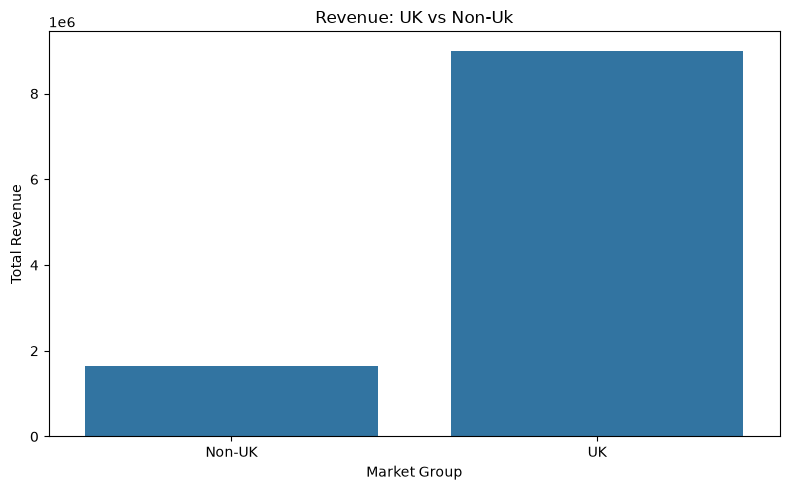

In [248]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=uk_non_uk_summary,
    x='market_group',
    y='total_revenue'
)

plt.title('Revenue: UK vs Non-Uk')
plt.xlabel('Market Group')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### 4.6.2 Orders

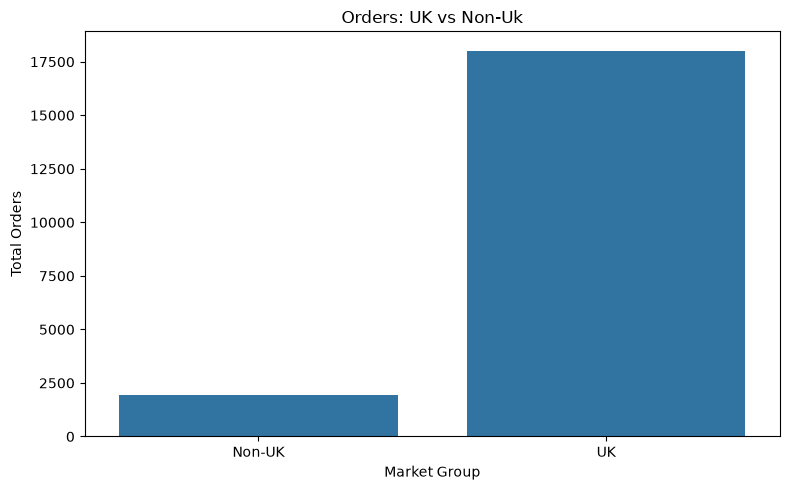

In [249]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=uk_non_uk_summary,
    x='market_group',
    y='total_orders'
)

plt.title('Orders: UK vs Non-Uk')
plt.xlabel('Market Group')
plt.ylabel('Total Orders')

plt.tight_layout()
plt.show()

### 4.6.3 Average Revenue per Order

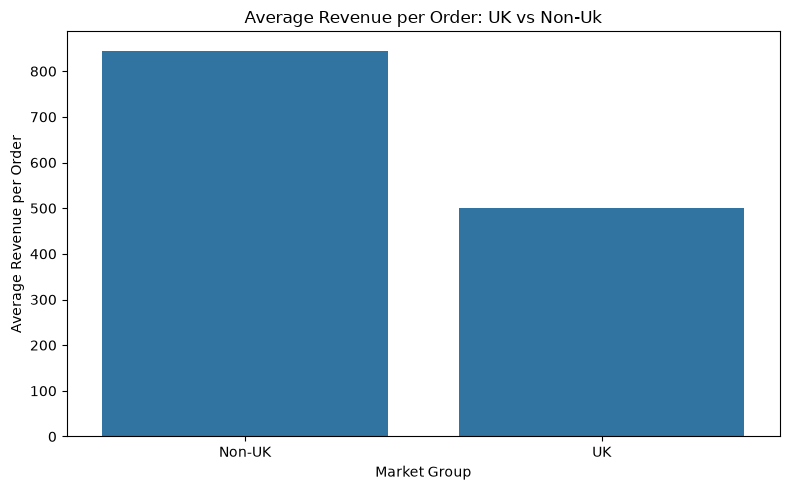

In [250]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=uk_non_uk_summary,
    x='market_group',
    y='average_revenue_per_order'
)

plt.title('Average Revenue per Order: UK vs Non-Uk')
plt.xlabel('Market Group')
plt.ylabel('Average Revenue per Order')

plt.tight_layout()
plt.show()

## 4.7 Top Countries

### 4.7.1 Top 10 Countries by Revenue

In [251]:
top_countries_revenue = (
    country_contribution[
        ['Country', 'total_revenue', 'revenue_contribution_pct']
    ]
    .sort_values('total_revenue', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_countries_revenue.insert(
    0,
    'rank',
    range(1, len(top_countries_revenue) + 1)
)

top_countries_revenue.style.format({
    'total_revenue': '{:,.2f}',
    'revenue_contribution_pct': '{:.2f}%'
})

,rank,Country,total_revenue,revenue_contribution_pct
0,1,United Kingdom,"9,001,744.09",84.59%
1,2,Netherlands,"285,446.34",2.68%
2,3,EIRE,"283,140.52",2.66%
3,4,Germany,"228,678.40",2.15%
4,5,France,"209,625.37",1.97%
5,6,Australia,"138,453.81",1.30%
6,7,Spain,"61,558.56",0.58%
7,8,Switzerland,"57,067.60",0.54%
8,9,Belgium,"41,196.34",0.39%
9,10,Sweden,"38,367.83",0.36%


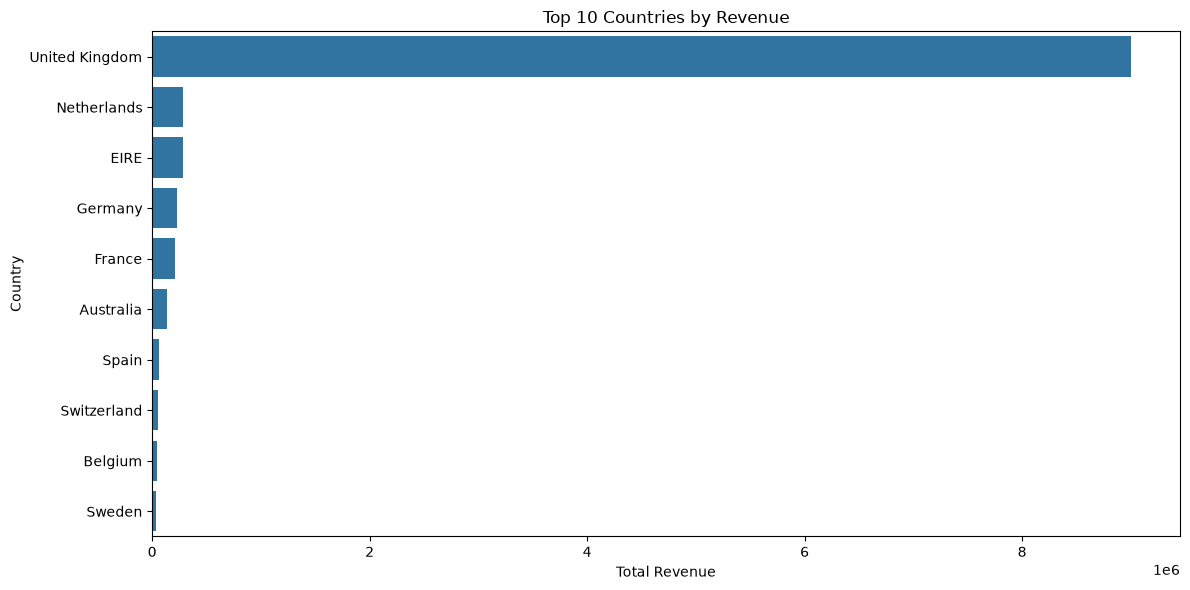

In [252]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_countries_revenue,
    x='total_revenue',
    y='Country'
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

### 4.7.2 Top 10 Countries by Orders

In [253]:
top_countries_orders = (
    country_aov[
        ['Country', 'total_orders']
    ]
    .sort_values('total_orders', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_countries_orders.insert(
    0,
    'rank',
    range(1, len(top_countries_orders) + 1)
)

top_countries_orders

,rank,Country,total_orders
0,1,United Kingdom,18019
1,2,Germany,457
2,3,France,392
3,4,EIRE,288
4,5,Belgium,98
5,6,Netherlands,94
6,7,Spain,90
7,8,Portugal,58
8,9,Australia,57
9,10,Switzerland,54


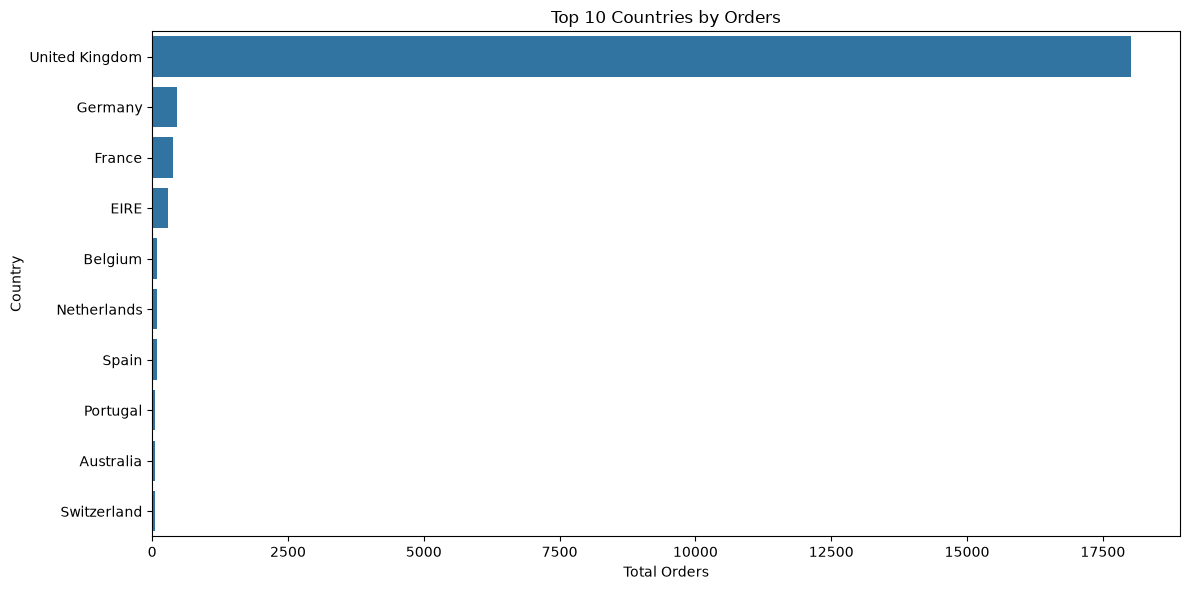

In [254]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_countries_orders,
    x='total_orders',
    y='Country'
)

plt.title('Top 10 Countries by Orders')
plt.xlabel('Total Orders')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

### 4.7.3 Top 10 Countries by Customers

In [255]:
country_customers = (
    df[df['CustomerID'].notna()]
    .groupby('Country')['CustomerID']
    .nunique()
    .reset_index(name='total_customers')
)

top_countries_customers = (
    country_customers
    .sort_values('total_customers', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_countries_customers.insert(
    0,
    'rank',
    range(1, len(top_countries_customers) + 1)
)

top_countries_customers

,rank,Country,total_customers
0,1,United Kingdom,3920
1,2,Germany,94
2,3,France,87
3,4,Spain,30
4,5,Belgium,25
5,6,Switzerland,21
6,7,Portugal,19
7,8,Italy,14
8,9,Finland,12
9,10,Austria,11


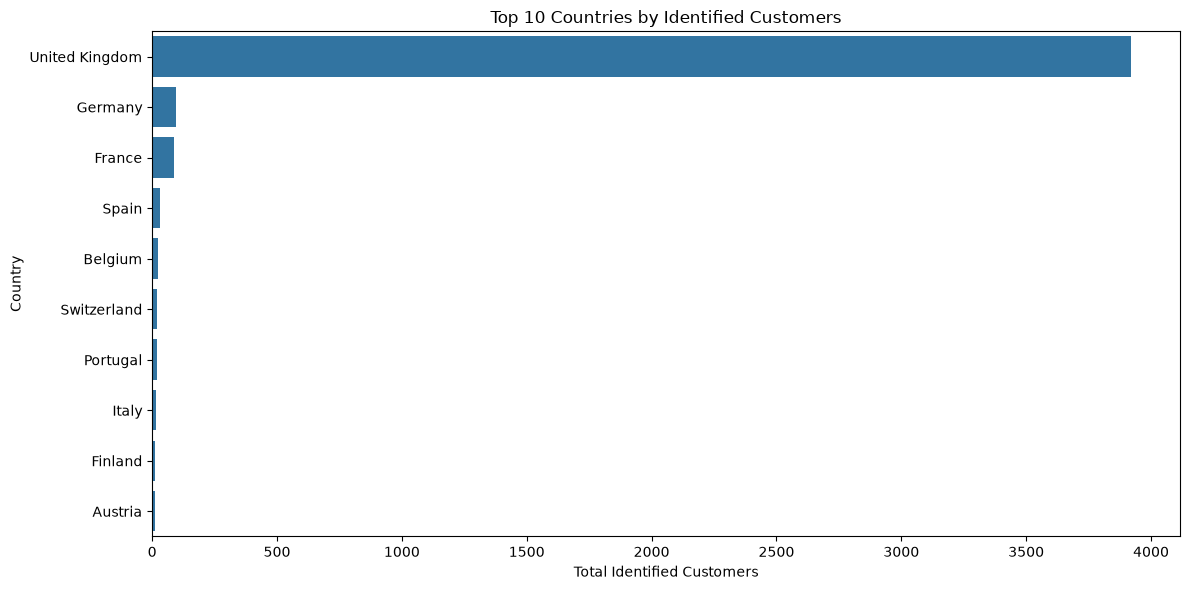

In [256]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_countries_customers,
    x='total_customers',
    y='Country'
)

plt.title('Top 10 Countries by Identified Customers')
plt.xlabel('Total Identified Customers')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

### 4.7.4 Combined Top Country Summary

In [257]:
top_country_summary = (
    country_contribution[
        ['Country', 'total_revenue', 'revenue_contribution_pct']
    ]
    .merge(
        country_aov[['Country', 'total_orders']],
        on='Country',
        how='left'
    )
    .merge(
        country_customers,
        on='Country',
        how='left'
    )
    .sort_values('total_revenue', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_country_summary.insert(
    0,
    'rank',
    range(1, len(top_country_summary) + 1)
)

top_country_summary.style.format({
    'total_revenue': '{:,.2f}',
    'revenue_contribution_pct': '{:.2f}%',
    'total_orders': '{:,.0f}',
    'total_customers': '{:,.0f}'
})

,rank,Country,total_revenue,revenue_contribution_pct,total_orders,total_customers
0,1,United Kingdom,"9,001,744.09",84.59%,"18,019","3,920"
1,2,Netherlands,"285,446.34",2.68%,94,9
2,3,EIRE,"283,140.52",2.66%,288,3
3,4,Germany,"228,678.40",2.15%,457,94
4,5,France,"209,625.37",1.97%,392,87
5,6,Australia,"138,453.81",1.30%,57,9
6,7,Spain,"61,558.56",0.58%,90,30
7,8,Switzerland,"57,067.60",0.54%,54,21
8,9,Belgium,"41,196.34",0.39%,98,25
9,10,Sweden,"38,367.83",0.36%,36,8


# 5. Product Supporting Analysis

## 5.1 Product Revenue & Quantity Summary

In [258]:
product_summary = (
    df.groupby('StockCode')
      .agg(
          total_revenue=('Revenue', 'sum'),
          total_quantity=('Quantity', 'sum'),
          total_orders=('invoice_no_normalized', 'nunique'),
          description=('Description', 'first')
      )
      .reset_index()
)

product_summary['average_revenue_per_order'] = (
    product_summary['total_revenue']
    / product_summary['total_orders']
)

product_summary = (
    product_summary
    .sort_values('total_revenue', ascending=False)
    .reset_index(drop=True)
)

product_summary.head(10)

,StockCode,total_revenue,total_quantity,total_orders,description,average_revenue_per_order
0,DOT,"206,248.77",706,706,DOTCOM POSTAGE,292.14
1,22423,"174,156.54",13851,1988,REGENCY CAKESTAND 3 TIER,87.60
2,23843,"168,469.60",80995,1,"PAPER CRAFT , LITTLE BIRDIE","168,469.60"
3,85123A,"104,462.75",37641,2198,WHITE HANGING HEART T-LIGHT HOLDER,47.53
4,47566,"99,445.23",18283,1685,PARTY BUNTING,59.02
5,85099B,"94,159.81",48371,2089,JUMBO BAG RED RETROSPOT,45.07
6,23166,"81,700.92",78033,247,MEDIUM CERAMIC TOP STORAGE JAR,330.77
7,POST,"78,101.88",3150,1126,POSTAGE,69.36
8,M,"77,750.27",6984,289,Manual,269.03
9,23084,"66,870.03",30739,994,RABBIT NIGHT LIGHT,67.27


In [259]:
product_summary[
    [
        'total_revenue',
        'total_quantity',
        'total_orders',
        'average_revenue_per_order'
    ]
].describe()

,total_revenue,total_quantity,total_orders,average_revenue_per_order
count,"3,922.00","3,922.00","3,922.00","3,922.00"
mean,"2,713.44","1,420.81",132.48,63.70
std,"7,970.74","3,579.84",193.89,"2,698.30"
min,0.00,1.00,1.00,0.00
25%,128.84,54.00,16.00,6.27
50%,681.47,369.50,65.00,10.95
75%,"2,220.40","1,393.75",165.00,17.76
max,"206,248.77","80,995.00","2,198.00","168,469.60"


### 5.2 Product Revenue Distribution

In [260]:
product_summary['total_revenue'].describe()

count     3,922.00
mean      2,713.44
std       7,970.74
min           0.00
25%         128.84
50%         681.47
75%       2,220.40
max     206,248.77
Name: total_revenue, dtype: float64

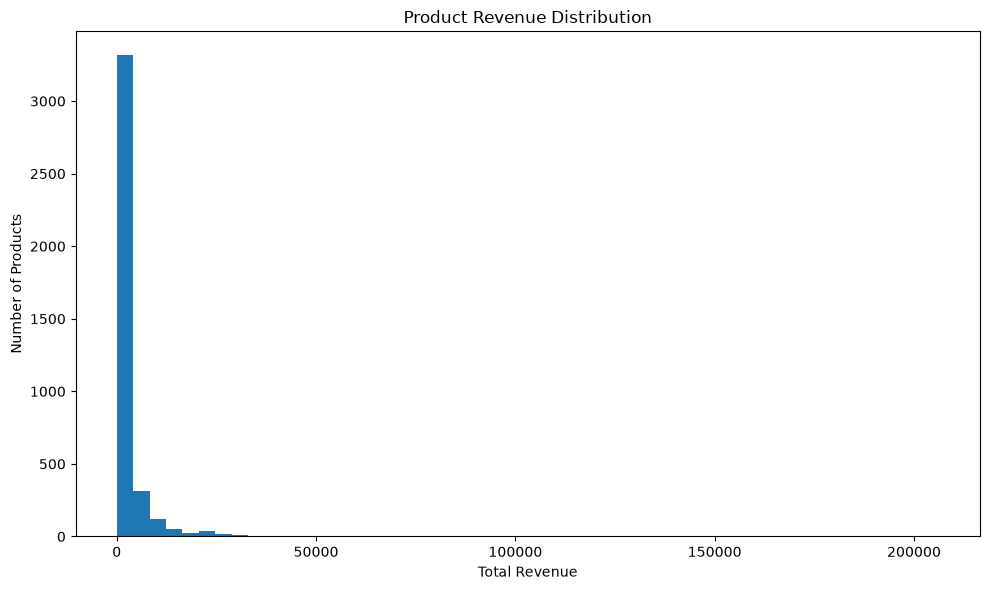

In [261]:
plt.figure(figsize=(10,6))

plt.hist(
    product_summary['total_revenue'],
    bins=50
)

plt.title('Product Revenue Distribution')
plt.xlabel('Total Revenue')
plt.ylabel('Number of Products')

plt.tight_layout()
plt.show()

## 5.3 Product Quantity Distribution

In [262]:
product_summary['total_quantity'].describe()

count    3,922.00
mean     1,420.81
std      3,579.84
min          1.00
25%         54.00
50%        369.50
75%      1,393.75
max     80,995.00
Name: total_quantity, dtype: float64

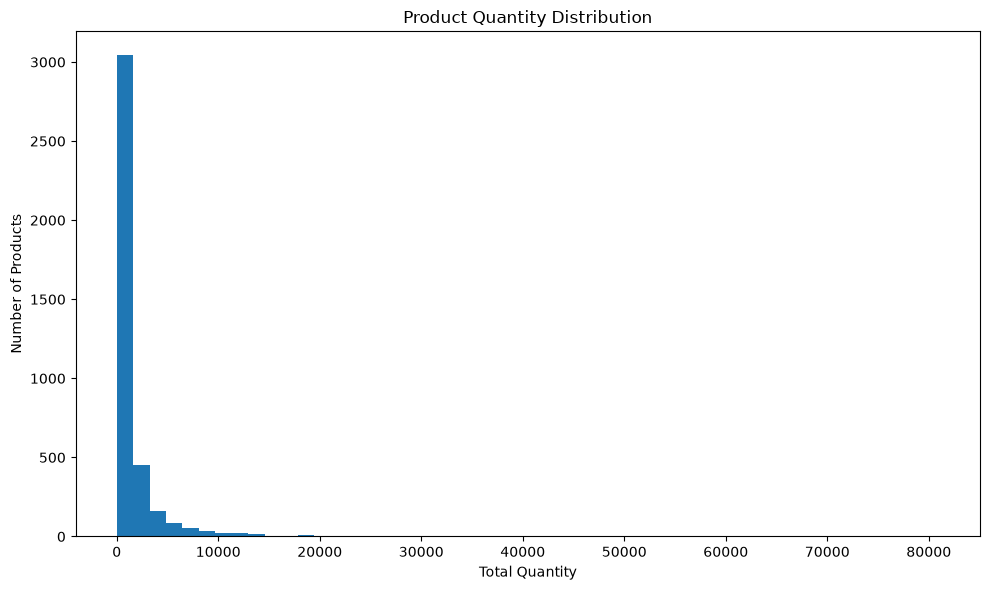

In [263]:
plt.figure(figsize=(10,6))

plt.hist(
    product_summary['total_quantity'],
    bins=50
)

plt.title('Product Quantity Distribution')
plt.xlabel('Total Quantity')
plt.ylabel('Number of Products')

plt.tight_layout()
plt.show()

## 5.4 Revenue vs Quantity

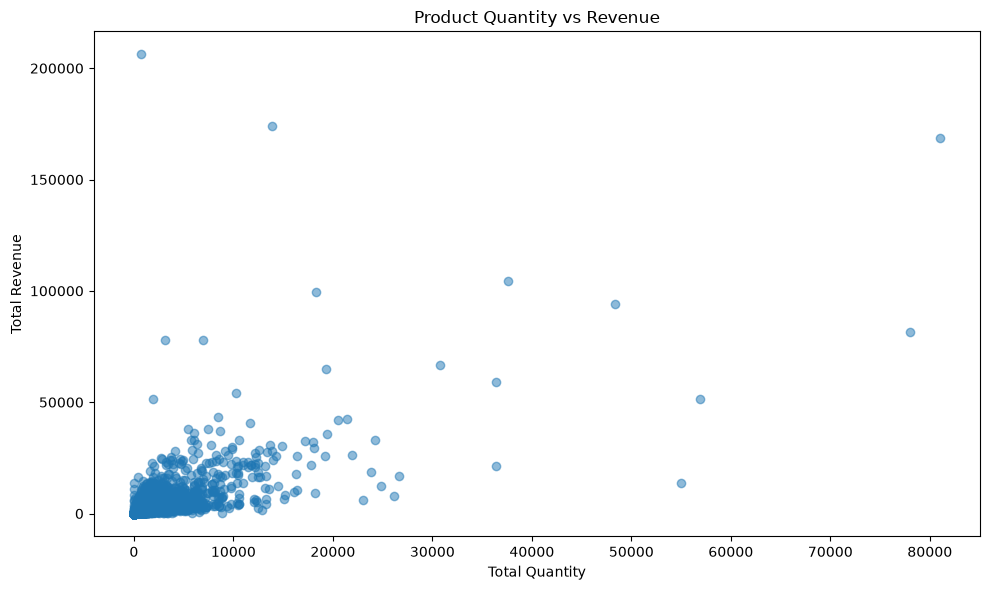

In [264]:
plt.figure(figsize=(10,6))

plt.scatter(
    product_summary['total_quantity'],
    product_summary['total_revenue'],
    alpha=0.5
)

plt.title('Product Quantity vs Revenue')
plt.xlabel('Total Quantity')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

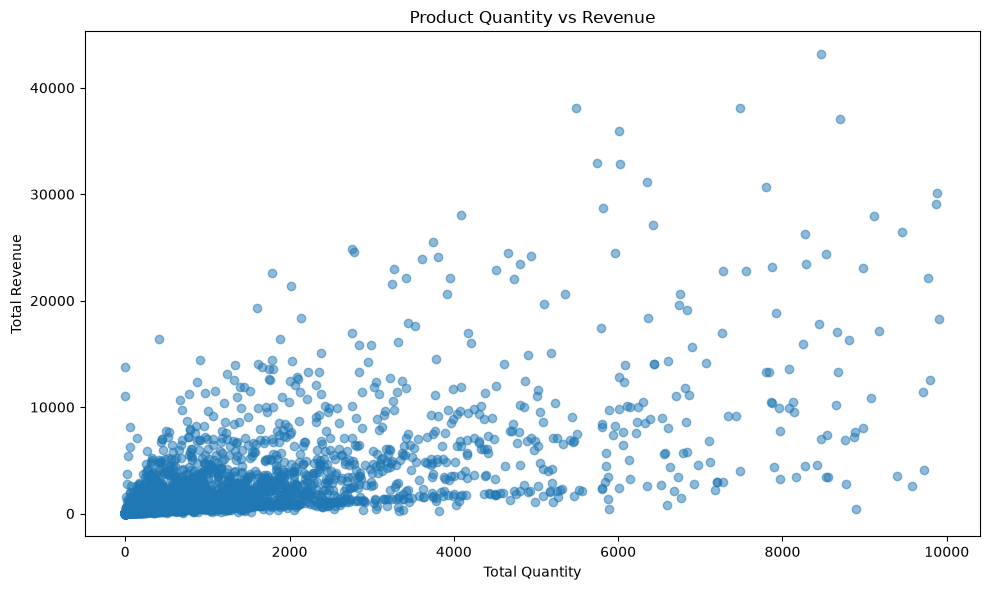

In [265]:
product_scatter = product_summary[
    (product_summary['total_quantity'] <= 10000) &
    (product_summary['total_revenue'] <= 50000)
]

plt.figure(figsize=(10,6))

plt.scatter(
    product_scatter['total_quantity'],
    product_scatter['total_revenue'],
    alpha=0.5
)

plt.title('Product Quantity vs Revenue')
plt.xlabel('Total Quantity')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

In [266]:
correlation = product_summary[
    ['total_quantity', 'total_revenue']
].corr().loc['total_quantity', 'total_revenue']

print(f"Quantity-Revenue correlation : {correlation:.4f}")

Quantity-Revenue correlation : 0.6587


## 5.5 High-Volume vs High-Value Products

In [267]:
quantity_threshold = product_summary['total_quantity'].median()
revenue_threshold = product_summary['total_revenue'].median()

print(f"Quantity threshold : {quantity_threshold:,.2f}")
print(f"Revenue threshold : {revenue_threshold:,.2f}")

Quantity threshold : 369.50
Revenue threshold : 681.47


In [268]:
product_position = product_summary.copy()

product_position['product_type'] = np.where(
    (product_position['total_quantity'] >= quantity_threshold) &
    (product_position['total_revenue'] >= revenue_threshold),
    'High Volume - High Value',
    np.where(
        (product_position['total_quantity'] >= quantity_threshold) &
        (product_position['total_revenue'] < revenue_threshold),
        'High Volume - Low Value',
        np.where(
            (product_position['total_quantity'] < quantity_threshold) &
            (product_position['total_revenue'] >= revenue_threshold),
            'Low Volume - High Value',
            'Low Volume - Low Value'
        )
    )
)

In [269]:
product_position['product_type'].value_counts()

product_type
High Volume - High Value    1670
Low Volume - Low Value      1670
Low Volume - High Value      291
High Volume - Low Value      291
Name: count, dtype: int64

In [270]:
for category in product_position['product_type'].unique():

    print(f"\n{'='*60}")
    print(category)
    print('='*60)

    display(
        product_position[
            product_position['product_type'] == category
        ][[
            'StockCode',
            'total_quantity',
            'total_revenue'
        ]]
        .sort_values('total_revenue', ascending=False)
        .head(10)
    )


High Volume - High Value


,StockCode,total_quantity,total_revenue
0,DOT,706,"206,248.77"
1,22423,13851,"174,156.54"
2,23843,80995,"168,469.60"
3,85123A,37641,"104,462.75"
4,47566,18283,"99,445.23"
5,85099B,48371,"94,159.81"
6,23166,78033,"81,700.92"
7,POST,3150,"78,101.88"
8,M,6984,"77,750.27"
9,23084,30739,"66,870.03"



Low Volume - High Value


,StockCode,total_quantity,total_revenue
151,AMAZONFEE,2,"13,761.09"
204,B,1,"11,062.06"
297,22655,60,"8,125.00"
351,C2,142,"7,051.00"
415,22826,58,"6,210.00"
439,23485,262,"5,843.92"
473,22827,35,"5,415.00"
482,22848,323,"5,208.45"
505,22849,323,"5,027.73"
523,23010,315,"4,879.60"



High Volume - Low Value


,StockCode,total_quantity,total_revenue
1961,21163,1196,680.55
1963,22136,378,679.28
1965,22062,583,677.86
1971,40001,821,675.23
1972,22267,836,673.17
1980,22535,1763,669.75
1982,22057,584,667.92
1984,47574A,548,665.20
1985,85199L,977,663.43
1988,23547,1575,661.50



Low Volume - Low Value


,StockCode,total_quantity,total_revenue
1962,46776B,161,679.67
1964,23597,249,679.07
1966,35001G,198,677.34
1967,21205,253,677.19
1968,22806,260,677.04
1969,84659A,280,676.27
1970,23428,77,675.91
1973,21351,104,672.88
1974,21696,224,672.40
1975,47591d,134,672.24


## 5.6 Product Outlier Analysis

### 5.6.1 Revenue Outlier Threshold

In [271]:
revenue_q1 = product_summary['total_revenue'].quantile(0.25)
revenue_q3 = product_summary['total_revenue'].quantile(0.75)

revenue_iqr = revenue_q3 - revenue_q1

revenue_lower_bound = revenue_q1 - (1.5 * revenue_iqr)
revenue_upper_bound = revenue_q3 + (1.5 * revenue_iqr)

print(f"Revenue Q1           : {revenue_q1:,.2f}")
print(f"Revenue Q3           : {revenue_q3:,.2f}")
print(f"Revenue IQR          : {revenue_iqr:,.2f}")
print(f"Revenue lower bound  : {revenue_lower_bound:,.2f}")
print(f"Revenue upper bound  : {revenue_upper_bound:,.2f}")

Revenue Q1           : 128.84
Revenue Q3           : 2,220.40
Revenue IQR          : 2,091.56
Revenue lower bound  : -3,008.50
Revenue upper bound  : 5,357.74


### 5.6.2 Quantity Outlier Threshold

In [272]:
quantity_q1 = product_summary['total_quantity'].quantile(0.25)
quantity_q3 = product_summary['total_quantity'].quantile(0.75)

quantity_iqr = quantity_q3 - quantity_q1

quantity_lower_bound = quantity_q1 - (1.5 * quantity_iqr)
quantity_upper_bound = quantity_q3 + (1.5 * quantity_iqr)

print(f"Quantity Q1           : {quantity_q1:,.2f}")
print(f"Quantity Q3           : {quantity_q3:,.2f}")
print(f"Quantity IQR          : {quantity_iqr:,.2f}")
print(f"Quantity lower bound  : {quantity_lower_bound:,.2f}")
print(f"Quantity upper bound  : {quantity_upper_bound:,.2f}")

Quantity Q1           : 54.00
Quantity Q3           : 1,393.75
Quantity IQR          : 1,339.75
Quantity lower bound  : -1,955.62
Quantity upper bound  : 3,403.38


### 5.6.3 Mark Product Outlier

In [273]:
product_outlier = product_summary.copy()

product_outlier['revenue_outlier'] = (
    product_outlier['total_revenue'] > revenue_upper_bound
)

product_outlier['quantity_outlier'] = (
    product_outlier['total_quantity'] > quantity_upper_bound
)

product_outlier['any_outlier'] = (
    product_outlier['revenue_outlier'] |
    product_outlier['quantity_outlier']
)

product_outlier['both_outlier'] = (
    product_outlier['revenue_outlier'] &
    product_outlier['quantity_outlier']
)

### 5.6.4 Outlier Summary

In [274]:
print(f"Total products              : {len(product_outlier):,}")
print(
    f"Revenue outlier products    : "
    f"{product_outlier['revenue_outlier'].sum():,}"
)
print(
    f"Quantity outlier products   : "
    f"{product_outlier['quantity_outlier'].sum():,}"
)
print(
    f"Any outlier products        : "
    f"{product_outlier['any_outlier'].sum():,}"
)
print(
    f"Both revenue & quantity     : "
    f"{product_outlier['both_outlier'].sum():,}"
)

Total products              : 3,922
Revenue outlier products    : 476
Quantity outlier products   : 401
Any outlier products        : 611
Both revenue & quantity     : 266


### 5.6.5 Top Revenue Outlier Products

In [275]:
revenue_outliers = (
    product_outlier[
        product_outlier['revenue_outlier']
    ]
    .sort_values('total_revenue', ascending=False)
)

display(
    revenue_outliers[
        [
            'StockCode',
            'total_revenue',
            'total_quantity',
            'total_orders'
        ]
    ].head(10)
)

,StockCode,total_revenue,total_quantity,total_orders
0,DOT,"206,248.77",706,706
1,22423,"174,156.54",13851,1988
2,23843,"168,469.60",80995,1
3,85123A,"104,462.75",37641,2198
4,47566,"99,445.23",18283,1685
5,85099B,"94,159.81",48371,2089
6,23166,"81,700.92",78033,247
7,POST,"78,101.88",3150,1126
8,M,"77,750.27",6984,289
9,23084,"66,870.03",30739,994


### 5.6.6 Top Quantity Outlier Products

In [276]:
quantity_outliers = (
    product_outlier[
        product_outlier['quantity_outlier']
    ]
    .sort_values('total_quantity', ascending=False)
)

display(
    quantity_outliers[
        [
            'StockCode',
            'total_quantity',
            'total_revenue',
            'total_orders'
        ]
    ].head(10)
)

,StockCode,total_quantity,total_revenue,total_orders
2,23843,80995,"168,469.60",1
6,23166,78033,"81,700.92",247
14,22197,56898,"51,334.47",1392
149,84077,54951,"13,814.01",535
5,85099B,48371,"94,159.81",2089
3,85123A,37641,"104,462.75",2198
87,21212,36396,"21,246.45",1320
11,84879,36362,"58,927.62",1455
9,23084,30739,"66,870.03",994
117,22492,26633,"16,937.82",380
